# CAP — Submission-ready figures

Main and supplementary manuscript figures. Styling, palette, panel lettering and export live in `figure_style.py`; data comes from `results_data.load_results` (as in `results.ipynb`) plus a few CSVs. Each figure is saved as a vector PDF (+ 600-dpi PNG) in `final_figures/`. Run with the `cap` conda env.

## Setup — style, palette, data

In [127]:
import os
import glob
import warnings
import importlib
import pickle
import hashlib

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Reload local helpers so edits to the .py modules are picked up on re-run.
import figure_style as fs
import results_data
import figure_stats as fst
for _m in (fs, results_data, fst):
    importlib.reload(_m)

from figure_style import (
    BLUE, LBLUE, DBLUE, RED, ORANGE, GRAY, MM,
    SINGLE_COL, INTER_COL, DOUBLE_COL, MAX_HEIGHT,
    style_ax, style_hbar_ax, label_panels, save_figure, MODEL_TYPE_COLORS,
    no_constrained_layout, SCATTER_KW, ERR_KW, BAR_ERR_KW,
)
from results_data import load_results, EMBED_TYPE, REPRO_CSV, EMBED_NATIVE_DIM

warnings.filterwarnings("ignore")
fs.set_nature_style()
os.makedirs("final_figures", exist_ok=True)

STAT_SEED, CI, N_BOOT = 0, 95.0, 1000
RECOMPUTE_STATS = True
STATS_CACHE = "cache_figure_stats.pkl"
print(f"Page widths (in): single={SINGLE_COL:.2f} inter={INTER_COL:.2f} double={DOUBLE_COL:.2f}")

Nature style set. Sans-serif font in use: DejaVuSans.ttf
Page widths (in): single=3.50 inter=4.72 double=7.20


In [128]:
results = load_results(
    os.environ["BIOPERT_OUTDIR"],
    lincs_beta_dir=os.environ.get("LINCS_BETA_DIR"),
)

# Pin Tahoe BioPert to the run reproduced for the Systema analysis. This
# replaces both its summary statistics and per-observation file source.
TAHOE_SYSTEMA_RUN = (
    "/network/scratch/l/lola.lebreton/transcriptomes/results/systema_tahoe/runs/"
    "filtered_pseudobulks_alpha_10000_tahoe_default_config_2026-08-06_185016"
)
_summary = results_data._read_summary(os.path.join(TAHOE_SYSTEMA_RUN, "summary.toml"))
_mask = results.best_runs["exp_key"].eq("tahoe_default_config")
assert _mask.sum() == 1, "expected exactly one Tahoe default run"
_idx = results.best_runs.index[_mask][0]
for _column, _value in _summary.items():
    if (_column in results.best_runs.columns
            and not (isinstance(_value, str) and _value == "nothing")):
        results.best_runs.at[_idx, _column] = _value
results.best_runs.at[_idx, "run_dir"] = TAHOE_SYSTEMA_RUN
results.best_runs.at[_idx, "timestamp"] = "2026-08-06_185016"

best_runs = results.best_runs
baselines_df = results.baselines_df

NO_GATE_ARM = {"default", "landmark_genes", "delta_ref_only"}
_GATE_SUFFIX = " + dose (gate)"

_br = results.best_runs
_gate = _br[(_br.category == "dose_encoding")
            & (_br.label.str.endswith(_GATE_SUFFIX))].copy()
_gate["label"] = _gate["label"].str.removesuffix(_GATE_SUFFIX)

_GATE_KEY_SUFFIX = "_dose_gate"
_gate["category"] = [
    results_data.EXPERIMENT_META[k.removesuffix(_GATE_KEY_SUFFIX)][1]
    for k in _gate["exp_key"]
]
assert _gate["category"].isin(["ablation", "embedding"]).all(), \
    "gate experiment whose base experiment is not an ablation/embedding"

_replaced = set(zip(_gate["dataset"], _gate["label"]))
_is_repl = pd.Series([k in _replaced for k in zip(_br["dataset"], _br["label"])],
                     index=_br.index)
_keep = ~(_br.category.isin(["ablation", "embedding"])
          & ~_br.label.isin(NO_GATE_ARM) & _is_repl)
best_runs = pd.concat([_br[_keep], _gate], ignore_index=True)
assert not best_runs[best_runs.category.isin(["ablation", "embedding"])] \
    .duplicated(subset=["dataset", "label"]).any(), "duplicate representation row"
print(f"Dose/time correction: {len(_gate)} gate experiments substituted for "
      f"{int((~_keep).sum())} dose-blind representation rows.")

res = best_runs[[
    "exp_key", "dataset", "category", "label", "n_train",
    "train_pearson", "val_pearson", "test_pearson",
    "train_spearman", "val_spearman", "test_spearman",
    "test_l2", "test_cosine_sim",
]].copy()
base = results.baseline_summary.copy()
print(res.shape, "experiments |", base.shape, "baseline rows")
res.head()

Completed runs: 4772  |  Experiments with ≥1 run: 106 / 108
Loading run_stats from cache (cache_run_stats.parquet)...
Dose/time correction: 36 gate experiments substituted for 34 dose-blind representation rows.
(108, 13) experiments | (4, 4) baseline rows


,exp_key,dataset,category,label,n_train,train_pearson,val_pearson,test_pearson,train_spearman,val_spearman,test_spearman,test_l2,test_cosine_sim
0,lincs_CheMeleon_dose_concat,LINCS,dose_encoding,CheMeleon + dose (concat),369199.0,0.179556,0.136966,0.121793,0.183190,0.135791,0.122650,14.844100,0.121722
1,lincs_CheMeleon_dose_gate,LINCS,dose_encoding,CheMeleon + dose (gate),369199.0,0.167334,0.138485,0.123571,0.167411,0.137290,0.123618,14.842521,0.123499
2,lincs_CheMeleon_dose_onehot,LINCS,dose_encoding,CheMeleon + dose (onehot),369199.0,0.192127,0.135766,0.115587,0.199663,0.136289,0.117674,14.918573,0.115361
3,lincs_ChemBERTa-100M-MLM_dose_gate,LINCS,dose_encoding,ChemBERTa-100M-MLM + dose (gate),369199.0,0.146088,0.119528,0.112653,0.146848,0.118631,0.112798,14.912414,0.112610
4,lincs_ChemBERTa-5M-MLM_dose_gate,LINCS,dose_encoding,ChemBERTa-5M-MLM + dose (gate),369199.0,0.144757,0.127689,0.114958,0.142853,0.123729,0.111854,14.920056,0.114903


## Statistics — confidence intervals and significance tests

Each experiment is a single val-best model, so all uncertainty is **sampling variability over the pinned, shared test set** — not training variance. All bootstrap intervals use 1,000 resamples. For representation comparisons, the notebook intersects the complete `(cell_line, drug, SMILES, dose, time)` identities across every displayed arm, reindexes every experiment and baseline to that one ordered cohort, and fails if identities are duplicated or unequal. Point estimates, percentile-bootstrap CIs, paired-bootstrap differences, and Wilcoxon tests all use those exact rows. Statistics are cached in `cache_figure_stats.pkl`; the cache signature includes the selected runs, complete shared-test identities, and bootstrap count.

In [129]:
# Build one exact test-observation cohort for every representation shown in a
# cross-model comparison. The compound split alone is insufficient: build_obs
# can drop different rows for different inputs. Include both drug and SMILES so
# distinct drug records with the same canonical structure remain distinct.
TEST_OBS_KEYS = ["cell_line", "drug", "smiles", "dose", "time"]
_RAW_PEROBS_CACHE = {}

def _load_raw_perobs(exp_key, split="test"):
    cache_key = (exp_key, split)
    if cache_key not in _RAW_PEROBS_CACHE:
        _RAW_PEROBS_CACHE[cache_key] = results.load_perobs_single(exp_key, split=split)
    return _RAW_PEROBS_CACHE[cache_key]

def _obs_index(df, name):
    missing = [c for c in TEST_OBS_KEYS if c not in df.columns]
    if missing:
        raise AssertionError(f"{name}: missing observation keys {missing}")
    idx = pd.MultiIndex.from_frame(df[TEST_OBS_KEYS], names=TEST_OBS_KEYS)
    if idx.has_duplicates:
        dup = int(idx.duplicated(keep=False).sum())
        raise AssertionError(f"{name}: {dup} rows have duplicate observation identities")
    return idx

def _restrict_to_obs_index(df, obs_index, name):
    idx = _obs_index(df, name)
    missing = obs_index.difference(idx)
    if len(missing):
        raise AssertionError(f"{name}: missing {len(missing)} required shared rows")
    out = df.set_index(TEST_OBS_KEYS, drop=False).reindex(obs_index).reset_index(drop=True)
    if not _obs_index(out, name).equals(obs_index):
        raise AssertionError(f"{name}: failed exact shared-row reindexing")
    return out

def _build_shared_split_views(exp_keys, family, split="test"):
    raw = {ek: _load_raw_perobs(ek, split=split) for ek in exp_keys}
    indices = {ek: _obs_index(df, ek) for ek, df in raw.items()}
    shared = set.intersection(*(set(idx.tolist()) for idx in indices.values()))
    if not shared:
        raise AssertionError(f"{family}: empty shared {split} set")
    obs_index = pd.MultiIndex.from_tuples(sorted(shared), names=TEST_OBS_KEYS)
    views = {ek: _restrict_to_obs_index(df, obs_index, ek) for ek, df in raw.items()}
    expected = len(obs_index)
    assert all(len(df) == expected for df in views.values())
    print(f"{family}: {expected:,} exact shared {split} observations across {len(views)} arms.")
    return views, obs_index

_REP_MASK = (res.category.isin(["ablation", "embedding"])
             & ~res.label.isin(["delta_ref_only"]))
REPRESENTATION_EXP_KEYS = {
    ds: res[_REP_MASK & res.dataset.eq(ds)]["exp_key"].drop_duplicates().tolist()
    for ds in ["Tahoe", "LINCS"]
}
_REP_PEROBS, _REP_TEST_INDEX = {}, {}
for _ds, _keys in REPRESENTATION_EXP_KEYS.items():
    _REP_PEROBS[_ds], _REP_TEST_INDEX[_ds] = _build_shared_split_views(
        _keys, f"{_ds} representation comparison")
_REP_EXP_TO_DATASET = {ek: ds for ds, keys in REPRESENTATION_EXP_KEYS.items() for ek in keys}

def get_perobs(exp_key):
    ds = _REP_EXP_TO_DATASET.get(exp_key)
    return (_REP_PEROBS[ds][exp_key] if ds is not None
            else _load_raw_perobs(exp_key, split="test"))

def _assert_same_test_rows(*frames):
    indices = [_obs_index(df, f"comparison experiment {i}") for i, df in enumerate(frames)]
    if any(not idx.equals(indices[0]) for idx in indices[1:]):
        raise AssertionError("comparison experiments do not have the exact same ordered test rows")

# res test-metric column -> per-observation score column.
METRIC_OBS_COL = {
    "test_pearson": "pearson", "test_spearman": "spearman",
    "test_l2": "l2", "test_cosine_sim": "cosine",
}
CI_COLS = [f"{m}_{b}" for m in METRIC_OBS_COL for b in ("lo", "hi")]

# Replace raw summary.toml test metrics with means over the exact shared cohort.
for _ds, _views in _REP_PEROBS.items():
    for _ek, _df in _views.items():
        _row = res["exp_key"].eq(_ek)
        assert _row.any(), f"missing res row for {_ek}"
        for _metric, _obs_col in METRIC_OBS_COL.items():
            res.loc[_row, _metric] = _df[_obs_col].mean()

# Restrict fixed baselines to those same rows before drawing or comparing them.
_BASELINE_PEROBS = {}
_base_rows = []
for _ds, _test_index in _REP_TEST_INDEX.items():
    for _bkey in ("delta_ref", "mean_delta"):
        _raw_b = baselines_df[(baselines_df.dataset == _ds)
                              & (baselines_df.baseline == _bkey)]
        if _raw_b.empty:
            raise AssertionError(f"missing {_ds} {_bkey} baseline")
        _b = _restrict_to_obs_index(_raw_b, _test_index, f"{_ds} {_bkey} baseline")
        _BASELINE_PEROBS[(_ds, _bkey)] = _b
        _base_rows.append({"dataset": _ds, "label": _b["label"].iloc[0],
                           "pearson": _b["pearson"].mean(),
                           "spearman": _b["spearman"].mean()})
base = pd.DataFrame(_base_rows)
SHARED_TEST_COUNTS = {ds: len(idx) for ds, idx in _REP_TEST_INDEX.items()}
_sig = hashlib.sha256()
for _ds in sorted(_REP_TEST_INDEX):
    _sig.update(_ds.encode())
    _sig.update(pd.util.hash_pandas_object(
        _REP_TEST_INDEX[_ds].to_frame(index=False), index=False).values.tobytes())
_selected_runs = (results.best_runs[["exp_key", "run_dir"]]
                  .sort_values(["exp_key", "run_dir"]))
_sig.update(_selected_runs.to_csv(index=False).encode())
SHARED_TEST_SIGNATURE = _sig.hexdigest()
SHARED_TEST_CACHE_VERSION = 3   # bumped: CI definition changed (back to i.i.d.)


def _compute_figure_stats():
    """Bootstrap 95% CIs per experiment/metric + paired tests. Returns
    (ci_df, repr_tests, headline_tests). Slow (reads every per-obs CSV)."""
    ci = res[["exp_key"]].drop_duplicates().copy()
    for metric, obs_col in METRIC_OBS_COL.items():
        los, his = [], []
        for ek in ci["exp_key"]:
            vals = get_perobs(ek)[obs_col].to_numpy()
            _, lo, hi = fst.bootstrap_ci_mean(
                vals, n_boot=N_BOOT, ci=CI, seed=STAT_SEED)
            los.append(lo); his.append(hi)
        ci[f"{metric}_lo"] = los
        ci[f"{metric}_hi"] = his

    repr_t, headline_t = {}, {}
    for ds in ["Tahoe", "LINCS"]:
        sub = res[(res.dataset == ds) & res.category.isin(["ablation", "embedding"])
                  & ~res.label.isin(["delta_ref_only", "random_512", "landmark_genes"])]
        rnd = res[(res.dataset == ds) & (res.label == "random_512")]
        if not rnd.empty:
            rnd_obs = get_perobs(rnd.iloc[0]["exp_key"])
            rows = []
            for _, r in sub.iterrows():
                arm_obs = get_perobs(r["exp_key"])
                _assert_same_test_rows(arm_obs, rnd_obs)
                d = fst.paired_delta(arm_obs, rnd_obs, metric="pearson",
                                     keys=TEST_OBS_KEYS, n_boot=N_BOOT, seed=STAT_SEED)
                d["label"] = r["label"]
                rows.append(d)
            padj = fst.bh_fdr([r["p"] for r in rows])
            for r, pa in zip(rows, padj):
                r["p_adj"] = float(pa)
                repr_t[(ds, r["label"])] = r

        emb = res[(res.dataset == ds) & (res.category == "embedding")]
        dflt = res[(res.dataset == ds) & (res.label == "default")]
        if not emb.empty and not dflt.empty:
            best_emb = emb.loc[emb["test_pearson"].idxmax()]
            dflt_obs = get_perobs(dflt.iloc[0]["exp_key"])
            emb_obs = get_perobs(best_emb["exp_key"])
            _assert_same_test_rows(dflt_obs, emb_obs)
            d = fst.paired_delta(dflt_obs, emb_obs, metric="pearson",
                                 keys=TEST_OBS_KEYS, n_boot=N_BOOT, seed=STAT_SEED)
            d["other"] = best_emb["label"]
            headline_t[(ds, "default_vs_best_embedding")] = d

        # Fig 2d/e bracket: BioPert vs the best non-BioPert representation shown
        # in the panel (same exclusions as representation_panel).
        rivals = res[(res.dataset == ds) & res.category.isin(["ablation", "embedding"])
                     & ~res.label.isin(["delta_ref_only", "landmark_genes", "default"])]
        if not dflt.empty and not rivals.empty:
            runner_up = rivals.loc[rivals["test_pearson"].idxmax()]
            dflt_obs = get_perobs(dflt.iloc[0]["exp_key"])
            ru_obs = get_perobs(runner_up["exp_key"])
            _assert_same_test_rows(dflt_obs, ru_obs)
            d = fst.paired_delta(dflt_obs, ru_obs, metric="pearson",
                                 keys=TEST_OBS_KEYS, n_boot=N_BOOT, seed=STAT_SEED)
            d["other"] = runner_up["label"]
            headline_t[(ds, "default_vs_runner_up")] = d

        if not dflt.empty:
            dflt_obs = get_perobs(dflt.iloc[0]["exp_key"])
            for bkey in ("delta_ref", "mean_delta"):
                bobs = _BASELINE_PEROBS[(ds, bkey)]
                _assert_same_test_rows(dflt_obs, bobs)
                d = fst.paired_delta(dflt_obs, bobs, metric="pearson",
                                     keys=TEST_OBS_KEYS, n_boot=N_BOOT, seed=STAT_SEED)
                headline_t[(ds, f"default_vs_{bkey}")] = d
    return ci, repr_t, headline_t


_cache_ok = False
if not RECOMPUTE_STATS and os.path.exists(STATS_CACHE):
    with open(STATS_CACHE, "rb") as fh:
        _cache = pickle.load(fh)
    _cache_ok = (_cache.get("shared_test_version") == SHARED_TEST_CACHE_VERSION
                 and _cache.get("shared_test_signature") == SHARED_TEST_SIGNATURE
                 and _cache.get("n_boot") == N_BOOT)
if _cache_ok:
    ci_df, repr_tests, headline_tests = (
        _cache["ci"], _cache["repr_tests"], _cache["headline_tests"])
    print(f"Loaded figure stats from {STATS_CACHE} "
          f"(seed={_cache.get('seed')}, CI={_cache.get('ci_level')}, "
          f"n_boot={_cache.get('n_boot')}).")
else:
    ci_df, repr_tests, headline_tests = _compute_figure_stats()
    with open(STATS_CACHE, "wb") as fh:
        pickle.dump({"ci": ci_df, "repr_tests": repr_tests,
                     "headline_tests": headline_tests,
                     "seed": STAT_SEED, "ci_level": CI,
                     "shared_test_version": SHARED_TEST_CACHE_VERSION,
                     "shared_test_counts": SHARED_TEST_COUNTS,
                     "n_boot": N_BOOT,
                     "shared_test_signature": SHARED_TEST_SIGNATURE}, fh)
    print(f"Computed figure stats and wrote {STATS_CACHE}.")

res = res.drop(columns=[c for c in CI_COLS if c in res.columns], errors="ignore")
res = res.merge(ci_df, on="exp_key", how="left")
res = res.drop_duplicates(ignore_index=True)

print("Headline paired comparisons (Δ mean Pearson, default − other):")
for (ds, comp), d in headline_tests.items():
    print(f"  {ds:5s} {comp:28s} Δ={d['mean_diff']:+.3f} "
          f"[{d['lo']:+.3f}, {d['hi']:+.3f}]  p={d['p']:.1e}  n={d['n_pairs']}")
n_sig = sum(1 for (ds, l), r in repr_tests.items() if r["p_adj"] < 0.05
            and r["mean_diff"] > 0)
print(f"Representations significantly above random control "
      f"(BH p<0.05): {n_sig}/{len(repr_tests)}")

Tahoe representation comparison: 7,767 exact shared test observations across 20 arms.
LINCS representation comparison: 39,980 exact shared test observations across 19 arms.
Computed figure stats and wrote cache_figure_stats.pkl.
Headline paired comparisons (Δ mean Pearson, default − other):
  Tahoe default_vs_best_embedding    Δ=+0.340 [+0.336, +0.344]  p=0.0e+00  n=7767
  Tahoe default_vs_runner_up         Δ=+0.340 [+0.336, +0.344]  p=0.0e+00  n=7767
  Tahoe default_vs_delta_ref         Δ=+0.289 [+0.287, +0.292]  p=0.0e+00  n=7767
  Tahoe default_vs_mean_delta        Δ=+0.437 [+0.433, +0.440]  p=0.0e+00  n=7767
  LINCS default_vs_best_embedding    Δ=+0.028 [+0.026, +0.030]  p=6.6e-215  n=39980
  LINCS default_vs_runner_up         Δ=+0.028 [+0.026, +0.030]  p=6.6e-215  n=39980
  LINCS default_vs_delta_ref         Δ=+0.090 [+0.088, +0.092]  p=0.0e+00  n=39980
  LINCS default_vs_mean_delta        Δ=+0.093 [+0.091, +0.095]  p=0.0e+00  n=39980
Representations significantly above random con

In [130]:
PRETTY = {
    "default": "BioPert",
    "landmark_genes": "BioPert (landmark)",
    "random_512": "Random",
    "delta_ref_only": "BioPert Δ only",
    "Morgan_512": "ECFP6-512",
    "Morgan_1024": "ECFP6-1024",
    "Morgan_2048": "ECFP6-2048",
}
def pretty(label):
    return PRETTY.get(label, label)

REF_COLORS = {"A549": "#984ea3", "A-172": "#e07b00", "COLO 205": "#27ae60", "PANC-1": RED}
REF_MARKERS = {"A549": "P", "A-172": "s", "COLO 205": "^", "PANC-1": "D"}

METRIC_LABEL = {
    "test_pearson": "Test Pearson r",
    "test_spearman": "Test Spearman ρ",
    "test_cosine_sim": "Test cosine similarity",
    "test_l2": "Test L2 (lower = better)",
}
plt.rcParams['hatch.linewidth'] = 0.5


# Bar colour grouped by model type (FM embeddings no longer share one colour).
def representation_color(category, label):
    if label == "default":
        return BLUE
    if label == "random_512":
        return "white"   # null control: white fill + black hatch, not a colour
    if label == "landmark_genes":
        return DBLUE
    if category == "embedding":
        return MODEL_TYPE_COLORS.get(EMBED_TYPE.get(label, ""), GRAY)
    return GRAY

# Shared model-type + baseline legend (same scheme for both datasets).
def repr_legend(fig, baselines=True, include_landmark=False, ncol=4):
    handles = [Patch(facecolor=BLUE, label="BioPert")]
    if include_landmark:
        handles.append(Patch(facecolor=DBLUE, label="BioPert (landmark)"))
    handles += [
        Patch(facecolor=MODEL_TYPE_COLORS["Molecular graph MPNN"], label="Molecular graph"),
        Patch(facecolor=MODEL_TYPE_COLORS["Morgan fingerprint"], label="ECFP6 fingerprint"),
        Patch(facecolor=MODEL_TYPE_COLORS["SMILES transformer"], label="SMILES transformer"),
        Patch(facecolor=MODEL_TYPE_COLORS["3D geometry (UniMol)"], label="3D geometry"),
        Patch(facecolor="white", edgecolor="black", hatch="///", label="Random control"),
    ]
    if baselines:
        handles += [
            Line2D([0], [0], color=RED, ls="-", lw=1.5, label="Reference CL Δ"),
            Line2D([0], [0], color=RED, ls="--", lw=1.5, label="Avg. train Δ"),
        ]
    fig.legend(handles=handles, loc="outside lower center", ncol=ncol,
               fontsize=6, frameon=False, handlelength=1.4, columnspacing=1.2)

def representation_panel(ax, dataset, metric="test_pearson",
                         draw_baselines=True, lower_better=False,
                         include_landmark=False, draw_bracket=False,
                         x_from_zero=False):
    """Horizontal-bar ranking of representations for one dataset, coloured by
    model type. `delta_ref_only` is always excluded; `landmark_genes` unless
    `include_landmark`. Error bars are the 95% bootstrap CI of the mean metric;
    baseline reference lines are drawn thick, on top of the bars. A single bracket
    marks BioPert vs the runner-up representation: with ~8k-40k paired conditions
    every pairwise test is significant, so per-row stars carry no information and
    only that one comparison is annotated."""
    exclude = ["delta_ref_only"] + ([] if include_landmark else ["landmark_genes"])
    sub = res[(res.dataset == dataset)
              & (res.category.isin(["ablation", "embedding"]))
              & (~res.label.isin(exclude))].copy()
    sub = sub.sort_values(metric, ascending=lower_better)  # best ends up at bottom
    y = np.arange(len(sub))
    colors = [representation_color(c, l) for c, l in zip(sub.category, sub.label)]

    xerr = None
    lo_col, hi_col = f"{metric}_lo", f"{metric}_hi"
    if lo_col in sub.columns and hi_col in sub.columns:
        xerr = np.vstack([sub[metric] - sub[lo_col], sub[hi_col] - sub[metric]])
    bars = ax.barh(y, sub[metric], color=colors, height=0.74, edgecolor="white",
            linewidth=0.3, zorder=3, xerr=xerr,
            error_kw={**BAR_ERR_KW, "capthick": 0, "zorder": 5})
    # Random control: white fill + black hatch — reads as "null".
    for bar, lab in zip(bars, sub.label):
        if lab == "random_512":
            bar.set_edgecolor("black")
            bar.set_hatch("///")
            
    for bar, lab in zip(bars, sub.label):
        if lab != "default" and lab != "landmark_genes":
            bar.set_alpha(0.7)

    ax.set_yticks(y)
    ax.set_yticklabels([pretty(l) for l in sub.label], fontsize=5.5)
    for tick, lab in zip(ax.get_yticklabels(), sub.label):
        if lab in ("default", "landmark_genes"):
            tick.set_fontweight("bold")
    ax.set_ylim(-0.7, len(sub) - 0.3)
    ax.set_xlabel(METRIC_LABEL.get(metric, metric))
    ax.set_title(dataset, fontweight="bold", loc="center")
    style_hbar_ax(ax)

    if draw_baselines and metric in ("test_pearson", "test_spearman"):
        col = "pearson" if metric == "test_pearson" else "spearman"
        bl = base[base.dataset == dataset].set_index("label")
        for lab, ls in [("delta_ref", "-"), ("mean train delta", "--")]:
            if lab in bl.index:
                ax.axvline(bl.loc[lab, col], ls=ls, lw=1.5, color=RED, zorder=6)
    ax.margins(x=0.02)
    if x_from_zero:
        ax.set_xlim(0, None)

    if draw_bracket and metric == "test_pearson":
        annotate_biopert_bracket(ax, sub, metric)
    return sub


def annotate_biopert_bracket(ax, sub, metric="test_pearson", pad=0.02, tip=0.16):
    """Bracket + stars joining BioPert to the runner-up representation in `sub`.

    p is the paired Wilcoxon of the same two arms (headline_tests), so the mark
    is the test, not a re-derivation from the plotted CIs.
    """
    order = list(sub.label)
    if "default" not in order or len(order) < 2:
        return
    ds = sub["dataset"].iloc[0]
    test = headline_tests.get((ds, "default_vs_runner_up"))
    if test is None:
        return
    y_top = order.index("default")
    if test["other"] not in order:
        return
    y_bot = order.index(test["other"])

    hi_col = f"{metric}_hi"
    right = max(sub.iloc[y][hi_col] if hi_col in sub.columns else sub.iloc[y][metric]
                for y in (y_top, y_bot))
    span = ax.get_xlim()[1] - ax.get_xlim()[0]
    x0 = right + pad * span
    x1 = x0 + tip * span
    ax.plot([x0, x1, x1, x0], [y_top, y_top, y_bot, y_bot],
            lw=0.6, color="black", clip_on=False, zorder=7)
    ax.text(x1 + 0.012 * span, (y_top + y_bot) / 2, fst.stars(test["p"]),
            ha="left", va="center", fontsize=6.5, clip_on=False, zorder=7)
    ax.set_xlim(ax.get_xlim()[0], max(ax.get_xlim()[1], x1 + 0.10 * span))

## Figure 1 — Model architecture overview

Schematic of CAP: the target cell line's untreated profile supplies cell-line context, and the compound is represented by **either** the reference cell line Δ-profile (its measured drug response) **or** a chemical-structure representation (fingerprint / foundation-model embedding) — the two are alternatives. The chosen compound representation is concatenated with the cell-line context and mapped by an MLP to the predicted target-cell Δ-profile. Keeps its bespoke box palette (schematic, not a data plot).

In [131]:
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch
from matplotlib.transforms import blended_transform_factory
from scipy.stats import pearsonr, bootstrap

BASE = "/network/scratch/l/lola.lebreton/transcriptomes"
DATASETS = ("tahoe", "lincs")
DS_LABELS = {"tahoe": "Tahoe", "lincs": "LINCS"}
DS_COLORS = {"tahoe": BLUE, "lincs": "#df6464"}

SAR_PATH = {ds: f"{BASE}/sar_metric_fix/{ds}/sar.csv" for ds in DATASETS}
REPRO_DIR = {ds: f"{BASE}/repro/{ds}" for ds in DATASETS}
HEXBIN_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "cap_blue", ["#e7ecfb", BLUE, DBLUE])

saved final_figures/fig1_model_overview.{pdf,png}


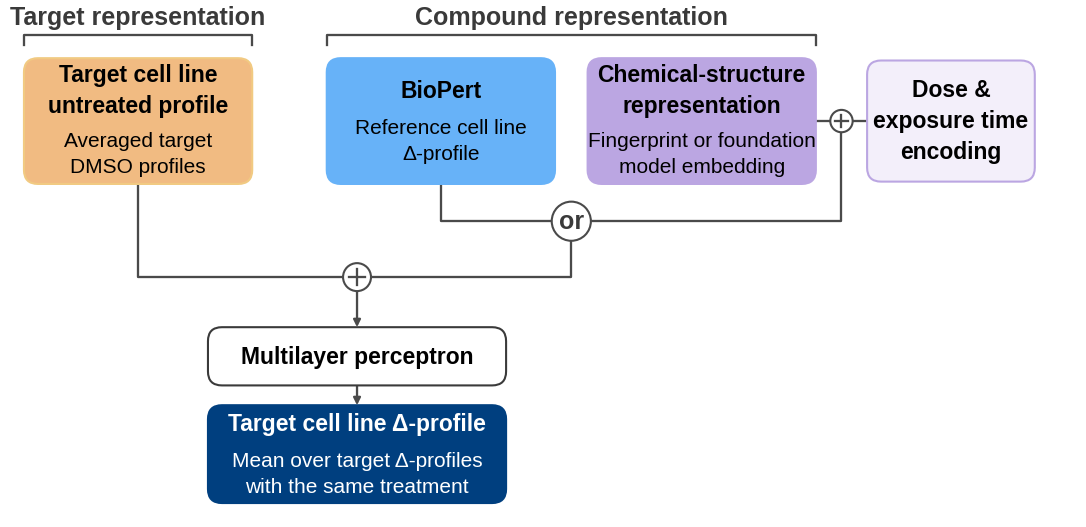

In [7]:
with no_constrained_layout():
    # Model-overview schematic — bespoke box palette kept; Nature fonts + save_figure.
    BOX_STYLE = {
        "dblue": dict(face="#003f7f", edge="#003f7f", title="white", body="white", role="#003f7f"),
        "orange": dict(face="#f1bb82", edge="#f1ca82", title="black", body="black", role="#f1ca82"),
        "red": dict(face="#df6464", edge="#df6464", title="black", body="black", role="#df6464"),
        "blue": dict(face="#67b2f8", edge="#67b2f8", title="black", body="black", role="#8A9098"),
        "purple": dict(face="#bba6e2", edge="#bba6e2", title="black", body="black", role="#bba6e2"),
        "pale_purple": dict(face="#f3effa", edge="#bba6e2", title="black", body="black", role="#bba6e2"),
        "plain": dict(face="#FFFFFF", edge="#3A3A3A", title="black", body="black", role="black"),
    }
    LINE, DASH_LINE = "#4A4A4A", "#A0A6AD"
    TITLE_FS, BODY_FS, ROLE_FS = 11, 10, 10
    LW_BOX, LW_LINK = 1.0, 1.1
    PT, LEAD, GROUP_GAP = 0.03528, 1.45, 0.28

    def box(ax, x, y, w, h, style, title, body=(), role=None, dashed=False):
        """Rounded box centred on (x, y); stacked title / body / role text rows."""
        c = BOX_STYLE[style]
        ax.add_patch(FancyBboxPatch(
            (x - w / 2, y - h / 2), w, h,
            boxstyle="round,pad=0,rounding_size=0.30", facecolor=c["face"],
            edgecolor=c["edge"], linewidth=LW_BOX,
            linestyle=(0, (4, 2.5)) if dashed else "solid", mutation_aspect=1, zorder=2))
        if isinstance(role, str):
            role = [role]
        groups = []
        if title:
            groups.append([(t, TITLE_FS, c["title"], "bold", "normal") for t in title])
        if body:
            groups.append([(t, BODY_FS, c["body"], "normal", "normal") for t in body])
        if role:
            groups.append([(t, ROLE_FS, c["role"], "normal", "italic") for t in role])
        total = sum(sum(fz * PT * LEAD * (txt.count("\n") + 1) for txt, fz, _, _, _ in g) for g in groups)
        total += GROUP_GAP * (len(groups) - 1)
        cursor = y + total / 2
        for gi, g in enumerate(groups):
            for txt, fz, col, weight, slant in g:
                lead = fz * PT * LEAD * (txt.count("\n") + 1)
                ax.text(x, cursor - lead / 2, txt, ha="center", va="center",
                        fontsize=fz, color=col, fontweight=weight, fontstyle=slant,
                        linespacing=LEAD, zorder=3)
                cursor -= lead
            if gi < len(groups) - 1:
                cursor -= GROUP_GAP

    def elbow(ax, x0, y0, x1, y1, dashed=False):
        """Vertical drop then horizontal run, joining a box to the concat node."""
        kw = dict(color=DASH_LINE if dashed else LINE, lw=LW_LINK, solid_capstyle="round", zorder=1)
        if dashed:
            kw["dashes"] = (4, 2.5)
        ax.plot([x0, x0, x1], [y0, y1, y1], **kw)

    def arrow(ax, x, y0, y1):
        ax.annotate("", xy=(x, y1), xytext=(x, y0),
                    arrowprops=dict(arrowstyle="-|>", color=LINE, lw=LW_LINK, shrinkA=0, shrinkB=0), zorder=1)

    def concat_node(ax, x, y, r=0.30):
        ax.add_patch(plt.Circle((x, y), r, facecolor="#FFFFFF", edgecolor=LINE, lw=LW_BOX, zorder=3))
        ax.plot([x - r * 0.55, x + r * 0.55], [y, y], color=LINE, lw=LW_LINK, zorder=4)
        ax.plot([x, x], [y - r * 0.55, y + r * 0.55], color=LINE, lw=LW_LINK, zorder=4)

    def or_node(ax, x, y, r=0.42):
        """White node carrying an italic 'or' — the reference-Δ and chemical-structure
        paths merge here (the analogue of the '+' concat node below)."""
        ax.add_patch(plt.Circle((x, y), r, facecolor="#FFFFFF", edgecolor=LINE, lw=LW_BOX, zorder=4))
        ax.text(x, y, "or", ha="center", va="center", fontsize=12, fontweight="bold", color="#3A3A3A", zorder=5)

    # widened right side to give the new "Dose & exposure time" box real margin
    XLIM, YLIM = 23.2, 11.2
    fig, ax = plt.subplots(figsize=(DOUBLE_COL, DOUBLE_COL * YLIM / XLIM))
    ax.set_xlim(0, XLIM); ax.set_ylim(0, YLIM); ax.set_aspect("equal"); ax.axis("off")
    bw, bh = 4.9, 2.7
    xg, xr, xk = 2.9, 9.4, 15.0                     # green / reference-Δ / chemical-structure
    x_cat = 7.6                                      # concat + downstream column
    y_in, y_merge, y_cat, y_mlp, y_out = 8.65, 6.5, 5.3, 3.6, 1.5
    x_or = (xr + bw / 2 + xk - bw / 2) / 2           # midpoint of the gap between the two options

    box(ax, xg, y_in, bw, bh, "orange", ["Target cell line\nuntreated profile"],
        ["Averaged target\nDMSO profiles"])
    box(ax, xr, y_in, bw, bh, "blue", ["BioPert"], ["Reference cell line\nΔ-profile"])
    box(ax, xk, y_in, bw, bh, "purple", ["Chemical-structure\nrepresentation"],
        ["Fingerprint or foundation\nmodel embedding"])

    # dose / exposure-time auxiliary box — feeds the chemical-structure branch only
    bw_d, bh_d = 3.6, 2.6
    x_dose = xk + bw / 2 + 1.1 + bw_d / 2
    box(ax, x_dose, y_in, bw_d, bh_d, "pale_purple", ["Dose &\nexposure time\nencoding"], dashed=False)

    # "Compound representation" = EITHER the reference Δ-profile OR a chemical-structure
    # encoding. Bracket the two options, mark the "or", and merge them into one input.
    bx0, bx1, by = xr - bw / 2, xk + bw / 2, y_in + bh / 2 + 0.5
    ax.plot([bx0, bx0, bx1, bx1], [by - 0.22, by, by, by - 0.22], color=LINE, lw=LW_LINK, zorder=2)
    ax.text(x_or, by + 0.12, "Compound representation", ha="center", va="bottom",
            fontsize=12, fontweight="bold", color="#3A3A3A", zorder=3)
    # "Cell line representation" bracket over the target-untreated box (the other input)
    ax.plot([xg - bw / 2, xg - bw / 2, xg + bw / 2, xg + bw / 2],
            [by - 0.22, by, by, by - 0.22], color=LINE, lw=LW_LINK, zorder=2)
    ax.text(xg, by + 0.12, "Target representation", ha="center", va="bottom",
            fontsize=12, fontweight="bold", color="#3A3A3A", zorder=3)
    # green -> concat (cell-line context)
    elbow(ax, xg, y_in - bh / 2, x_cat - 0.30, y_cat)
    # the two options drop and merge at an "or" node into one compound line
    R_OR = 0.42
    elbow(ax, xr, y_in - bh / 2, x_or - R_OR, y_merge)

    # chemical-structure branch merges with dose/exposure-time via a "+" node placed
    # at the midpoint of the gap between the two boxes' facing edges (not their
    # centers, since the boxes are different widths), then drops into the "or" merge
    r_dose = 0.24
    x_plus = ((xk + bw / 2) + (x_dose - bw_d / 2)) / 2
    y_plus = y_in
    ax.plot([xk + bw / 2, x_plus - r_dose], [y_plus, y_plus], color=LINE, lw=LW_LINK, zorder=1)
    ax.plot([x_plus + r_dose, x_dose - bw_d / 2], [y_plus, y_plus], color=LINE, lw=LW_LINK, zorder=1)
    concat_node(ax, x_plus, y_plus, r=r_dose)
    ax.plot([x_plus, x_plus, x_or + R_OR], [y_plus - r_dose, y_merge, y_merge], color=LINE, lw=LW_LINK, zorder=1)

    or_node(ax, x_or, y_merge, R_OR)
    ax.plot([x_or, x_or, x_cat + 0.30], [y_merge - R_OR, y_cat, y_cat], color=LINE, lw=LW_LINK, zorder=1)

    concat_node(ax, x_cat, y_cat)
    arrow(ax, x_cat, y_cat - 0.30, y_mlp + 0.625)
    box(ax, x_cat, y_mlp, 6.4, 1.25, "plain", ["Multilayer perceptron"])
    arrow(ax, x_cat, y_mlp - 0.625, y_out + 1.05)
    box(ax, x_cat, y_out, 6.4, 2.1, "dblue", ["Target cell line Δ-profile"],
        ["Mean over target Δ-profiles\nwith the same treatment"])
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    save_figure(fig, "fig1_model_overview")
    plt.show()

## Figure 2 — Representations and structure–activity relationship

*(Merged from the former Fig 2 "SAR" and Fig 3 "Representations" — the two answered the same question from opposite directions. Figs 4–8 renumber down to 3–7.)*

**(a)** Correlation of each compound representation's pairwise chemical distance with Δ-profile Pearson r, Tahoe ● vs LINCS ■, with 95% pair-bootstrap CIs. Each representation uses the distance appropriate to its type: **Tanimoto** for the binary fingerprints (ECFP6, RDKit path, atom pair, MACCS) and **cosine** for the continuous embeddings. **(b, c)** Density of drug pairs in (ECFP6 Tanimoto distance, Δ-profile Pearson r) for Tahoe and LINCS, respectively, with matching y-axes; on-panel *r* is the correlation between the axes. Each hexbin keeps its own colorbar — the two count scales are independent. **ECFP6** (Morgan, radius 3) is the fingerprint plotted in (b, c). **(d, e)** Ranking of every compound representation by test Pearson r for Tahoe and LINCS, respectively, with 95% bootstrap CIs of the mean and independent x-scales. The bracket joins BioPert to the best-performing competing representation, marked with the paired Wilcoxon significance of that one comparison. Bars are coloured by model type; **Random** (a 512-d random embedding) is the white/hatched null control; the RED rules are the copy-reference-Δ (solid) and train-mean-Δ (dashed) baselines. The fingerprint rows are labelled **ECFP6-<bits>**: they are Morgan fingerprints of radius 3, which is ECFP6 by the usual diameter convention. One bit width (2048) is shown per fingerprint family in (a), since width does not change the picture (see d, e). **(f)** Tahoe Systema sensitivity analysis: Pearson correlation before and after subtracting a training-derived generic perturbation centroid, plus Systema centroid accuracy against other drugs measured in the same target cell line and dose. **(g)** Macro-Pearson gain over copying the reference-cell Δ in three explicit regimes: the default unseen-compound setting, an unseen target cell line with a seen compound, and both target cell line and compound unseen. Tahoe and LINCS are paired within each regime; error bars are 95% cell-line-bootstrap CIs.

In (f), **Standard BioPert** is the ordinary uncentered test Pearson used elsewhere, not a control experiment. Blue bars are BioPert-derived scores; fine and broad white hatching distinguish cell and cell + dose correction, respectively. The white bar with fine black hatching is the matched cell + dose centroid baseline, using the same null styling as Random in (d, e). **Systema centroid accuracy** is the published normalized-rank metric: for each prediction, the fraction of competing observed centroids farther away in Euclidean distance than its matched observed centroid. It is not top-1 accuracy, although a score of 1 indicates a top-1 match. The centroid prediction is identical for every condition within a cell-line × dose context, so its mean rank is exactly 0.5 by symmetry (the chance-ranking baseline, absent ties). Both the training centroid and test competitors are matched on target cell line and dose. In (g), BioPert and the copied-reference baseline are evaluated on the same paired observations; each is averaged within cell line and then equally across cell lines, and the plotted bar is BioPert macro Pearson minus reference macro Pearson.

Every chemical/foundation-model encoder collapses onto the random control (d, e), and a–c show why directly in the data: chemical similarity barely predicts response similarity — weakly negative on LINCS (strongest for Tanimoto), essentially absent on Tahoe. The reference-response model (**BioPert**) sits far to the right of every structural representation and of the copy-reference baseline. Its advantage is not merely recovery of a generic treatment program: most correlation remains after matched-dose Systema centering and the correct drug response has high Systema centroid accuracy (f). The learned transfer also improves over copying the reference response when the target cell line is unseen (g).

Only one significance bracket is drawn. With ~8k–40k paired conditions the Wilcoxon test flags ±0.01 shifts at p<1e-40, so per-row stars would read \*\*\* almost everywhere and carry no information; the single BioPert-vs-runner-up bracket marks the one comparison the panel is making, and the message elsewhere remains effect size, not significance. Every pairwise paired test is still exported to the stats CSVs.

**Every compound representation in (d, e) is its explicit dose/time-encoded (`gate`) arm, not the dose-blind original sweep** — a paper-wide correction applied once in the setup cell. BioPert's `delta_ref` input carries dose and exposure time implicitly, so comparing it against dose-blind encoders would confound an information gap with a representation gap. Encoding lifts every representation (see the dose/time supplementary figure), yet the ranking and the conclusion are unchanged: the gap to BioPert stays large, and the **Random** control still matches or beats most learned encoders on equal information. SAR panels (a–c) ported from `sar.ipynb`.

In [133]:
# SAR data + correlation of each chemical distance with Δ-profile Pearson r.
sar = {ds: pd.read_csv(SAR_PATH[ds], sep=";") for ds in DATASETS}
for ds, df in sar.items():
    print(f"{DS_LABELS[ds]}: {len(df):,} drug pairs")

FP_ROWS = {
    "ECFP6_2048": "ECFP6",
    "RDKit_2048": "RDKit path",
    "AtomPair_2048": "Atom pair",
    "MACCS_166": "MACCS",
}
EMB_ROWS = {
    "CheMeleon": "CheMeleon",
    "MoLFormer-XL-both-10pct": "MoLFormer-XL",
    "MolGen-large": "MolGen-large",
    "bert-base-smiles": "bert-base-smiles",
    "ChemBERTa-5M-MLM": "ChemBERTa-5M-MLM",
    "ChemBERTa-5M-MTR": "ChemBERTa-5M-MTR",
    "ChemBERTa-77M-MLM": "ChemBERTa-77M-MLM",
    "ChemBERTa-100M-MLM": "ChemBERTa-100M-MLM",
    "unimolv1_84m": "UniMolv1-84M",
    "unimolv2_84m": "UniMolv2-84M",
    "unimolv2_164m": "UniMolv2-164M",
    "unimolv2_310m": "UniMolv2-310M",
    "unimolv2_570m": "UniMolv2-570M",
    "unimolv2_1.1B": "UniMolv2-1.1B",
    "random_512": "Random",
}
EROW_LABELS = {**FP_ROWS, **EMB_ROWS}
EROW_PIN = "ECFP6_2048"
# Main-figure subset: all fingerprints, one ChemBERTa, one UniMol, the rest of
# the foundation models, and the random control. Full set is in the supplement.
EROW_MAIN = [*FP_ROWS, "CheMeleon", "MoLFormer-XL-both-10pct", "MolGen-large",
             "bert-base-smiles", "ChemBERTa-77M-MLM", "unimolv2_310m", "random_512"]

def bootstrap_corr_ci(y, X_df, n_resamples=N_BOOT, seed=STAT_SEED):
    """Pair-bootstrap 95% CI for the Pearson corr between y and each column of X."""
    rng = np.random.default_rng(seed)
    lo, hi = {}, {}
    for col in X_df.columns:
        res = bootstrap(
            (y, X_df[col].values),
            statistic=lambda a, b, axis: pearsonr(a, b, axis=axis)[0],
            vectorized=True, paired=True, n_resamples=n_resamples,
            confidence_level=0.95, method="percentile", random_state=rng)
        lo[col], hi[col] = res.confidence_interval.low, res.confidence_interval.high
    return pd.Series(lo), pd.Series(hi)

corr, corr_ci = {}, {}
for ds, df in sar.items():
    dist_cols = [f"{k}_dist" for k in EROW_LABELS if f"{k}_dist" in df.columns]
    missing = [k for k in EROW_LABELS if f"{k}_dist" not in df.columns]
    if missing:
        print(f"  [{ds}] missing distance columns: {missing}")
    corr[ds] = df[["pearson"] + dist_cols].corr().loc["pearson", dist_cols]
    corr_ci[ds] = bootstrap_corr_ci(df["pearson"].values, df[dist_cols])

corr_df_full = pd.concat({ds: corr[ds] for ds in DATASETS}, axis=1)
ci_lo_full = pd.concat({ds: corr_ci[ds][0] for ds in DATASETS}, axis=1)
ci_hi_full = pd.concat({ds: corr_ci[ds][1] for ds in DATASETS}, axis=1)
_expected_sar = [f"{k}_dist" for k in EROW_LABELS]
_missing_sar = {
    ds: [metric for metric in _expected_sar if metric not in corr[ds].index]
    for ds in DATASETS
}
assert not any(_missing_sar.values()), f"Incomplete full SAR inputs: {_missing_sar}"
assert corr_df_full.loc[_expected_sar, list(DATASETS)].notna().all().all(), (
    "Full SAR results contain missing correlations"
)
_pin = f"{EROW_PIN}_dist"
_full_rest = corr_df_full.loc[_expected_sar].drop(_pin)["lincs"].sort_values(ascending=False).index
_full_order = list(_full_rest) + [_pin]
corr_df_full = corr_df_full.loc[_full_order]
ci_lo_full, ci_hi_full = ci_lo_full.loc[_full_order], ci_hi_full.loc[_full_order]

_main = [f"{k}_dist" for k in EROW_MAIN]
rest = corr_df_full.loc[_main].drop(_pin)["lincs"].sort_values(ascending=False).index
order = list(rest) + [_pin]
corr_df, ci_lo, ci_hi = (
    corr_df_full.loc[order], ci_lo_full.loc[order], ci_hi_full.loc[order]
)

SYSTEMA_ROOT = os.getenv(
    "SYSTEMA_RESULTS_ROOT",
    "/network/scratch/l/lola.lebreton/transcriptomes/results/systema_tahoe",
)
systema_cell = pd.read_csv(os.path.join(SYSTEMA_ROOT, "analysis", "metrics_per_condition.csv"))
systema_dose = pd.read_csv(os.path.join(SYSTEMA_ROOT, "analysis_by_dose", "metrics_per_condition.csv"))
SYSTEMA_KEYS = ["cell_line", "drug", "dose", "time"]
assert systema_cell[[*SYSTEMA_KEYS, "method"]].equals(
    systema_dose[[*SYSTEMA_KEYS, "method"]]
)

def _clustered_systema_row(frame, column, group, label, marker):
    mean, lo, hi = fst.bootstrap_ci_mean(
        frame[column], n_boot=N_BOOT, ci=CI, seed=STAT_SEED,
        cluster_by=frame["drug"],
    )
    return dict(group=group, label=label, marker=marker, estimate=mean,
                lo=lo, hi=hi, n_conditions=len(frame),
                n_compounds=frame["drug"].nunique())

_sys_cell_bio = systema_cell.query("method == 'biopert'")
_sys_dose_bio = systema_dose.query("method == 'biopert'")
_sys_dose_mean = systema_dose.query("method == 'perturbed_mean'")
fig2_systema = pd.DataFrame([
    _clustered_systema_row(_sys_dose_bio, "pearson_control",
                            "Pearson r", "Standard BioPert", "o"),
    _clustered_systema_row(_sys_cell_bio, "pearson_systema",
                            "Pearson r", "Cell-line centroid", "o"),
    _clustered_systema_row(_sys_dose_bio, "pearson_systema",
                            "Pearson r", "Cell-line + dose", "o"),
    _clustered_systema_row(_sys_dose_mean, "centroid_accuracy",
                            "Systema centroid accuracy", "Perturbed mean", "s"),
    _clustered_systema_row(_sys_dose_bio, "centroid_accuracy",
                            "Systema centroid accuracy", "BioPert", "o"),
])

FIG2_CELLLINE_EXP = {"Tahoe": "tahoe_cellline_holdout",
                      "LINCS": "lincs_cellline_holdout"}
FIG2_DEFAULT_EXP = {"Tahoe": "tahoe_default_config",
                    "LINCS": "lincs_default_config"}
fig2_generalization_rows = []
for _ds, _ek in FIG2_CELLLINE_EXP.items():
    _obs = results.load_quadrant_baselines(_ek, metric="pearson",
                                           baselines=("delta_ref",))
    # Q2 identifies the explicitly test-held-out compound set and Q3 the
    # explicitly test-held-out cell-line set. Restrict Q4 to their strict
    # intersection so validation-held-out identities cannot enter the score.
    _test_cell_lines = set(_obs.loc[_obs["quadrant"] == "Q3", "cell_line"])
    _test_compounds = set(
        results.load_perobs_single(FIG2_DEFAULT_EXP[_ds], split="test")["smiles"]
    )
    for _q in ("Q2", "Q3", "Q4"):
        _g = (_obs[_obs.quadrant == _q].copy()
              .dropna(subset=["pearson", "pearson__delta_ref"]))
        if _q == "Q4":
            _g = _g.loc[
                _g["cell_line"].isin(_test_cell_lines)
                & _g["smiles"].isin(_test_compounds)
            ]
        _g["paired_gain"] = _g["pearson"] - _g["pearson__delta_ref"]
        _per_cl = _g.groupby("cell_line", observed=True).agg(
            model=("pearson", "mean"),
            baseline=("pearson__delta_ref", "mean"),
            gain=("paired_gain", "mean"),
            n_obs=("pearson", "size"),
        )
        _mean, _lo, _hi = fst.bootstrap_ci_mean(
            _per_cl["gain"], n_boot=N_BOOT, ci=CI, seed=STAT_SEED,
        )
        fig2_generalization_rows.append(dict(
            dataset=_ds, quadrant=_q, estimate=_mean, lo=_lo, hi=_hi,
            model_macro=_per_cl["model"].mean(),
            baseline_macro=_per_cl["baseline"].mean(),
            n_cell_lines=len(_per_cl), n_obs=len(_g),
            wins=int((_per_cl["gain"] > 0).sum()),
        ))
fig2_generalization = pd.DataFrame(fig2_generalization_rows)

print("Fig. 2f Systema estimates:")
print(fig2_systema[["group", "label", "estimate", "lo", "hi"]].round(3).to_string(index=False))
print("\nFig. 2g unseen-cell-line gains over reference Δ:")
print(fig2_generalization.round(3).to_string(index=False))

Tahoe: 5,102 drug pairs
LINCS: 20,016 drug pairs
Fig. 2f Systema estimates:
                    group              label  estimate    lo    hi
                Pearson r   Standard BioPert     0.791 0.773 0.806
                Pearson r Cell-line centroid     0.733 0.715 0.752
                Pearson r   Cell-line + dose     0.726 0.708 0.743
Systema centroid accuracy     Perturbed mean     0.500 0.445 0.554
Systema centroid accuracy            BioPert     0.961 0.947 0.973

Fig. 2g unseen-cell-line gains over reference Δ:
dataset quadrant  estimate    lo    hi  model_macro  baseline_macro  n_cell_lines  n_obs  wins
  Tahoe       Q2     0.295 0.280 0.310        0.811           0.516            35   5834    35
  Tahoe       Q3     0.078 0.061 0.095        0.525           0.447             7   5678     7
  Tahoe       Q4     0.042 0.024 0.058        0.492           0.450             7   1104     7
  LINCS       Q2     0.115 0.096 0.132        0.218           0.104           167  34641   1

In [134]:
res.sort_values("test_pearson") #.label.unique()

,exp_key,dataset,category,label,n_train,train_pearson,val_pearson,test_pearson,train_spearman,val_spearman,...,test_l2,test_cosine_sim,test_pearson_lo,test_pearson_hi,test_spearman_lo,test_spearman_hi,test_l2_lo,test_l2_hi,test_cosine_sim_lo,test_cosine_sim_hi
34,lincs_unimolv2_1.1B_dose_onehot,LINCS,dose_encoding,UniMolv2-1.1B + dose (onehot),369199.0,0.178862,0.083728,0.076448,0.186423,0.084782,...,15.058763,0.076344,0.074534,0.078240,0.076015,0.079915,15.006071,15.108738,0.074414,0.078151
32,lincs_unimolv2_1.1B_dose_concat,LINCS,dose_encoding,UniMolv2-1.1B + dose (concat),369199.0,NaN,0.087701,0.081416,NaN,0.086261,...,15.053604,0.081266,0.079693,0.083237,0.078011,0.081708,15.001007,15.103914,0.079539,0.083105
25,lincs_default_repro_0.5,LINCS,repro,repro_0.5,7492.0,0.883620,0.106903,0.083673,0.860180,0.095296,...,20.179482,0.083574,0.081660,0.085823,0.070932,0.075269,20.123215,20.243193,0.081590,0.085752
24,lincs_default_repro_0.4,LINCS,repro,repro_0.4,11440.0,0.842866,0.116388,0.091878,0.818326,0.108083,...,17.957312,0.091766,0.089496,0.094290,0.083253,0.088124,17.900096,18.016818,0.089345,0.094133
29,lincs_random_512_dose_onehot,LINCS,dose_encoding,random_512 + dose (onehot),369199.0,0.134143,0.105291,0.093038,0.133577,0.102288,...,14.958643,0.092754,0.091510,0.094630,0.088768,0.092016,14.906012,15.009585,0.091208,0.094343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40,tahoe_CVCL_0218,Tahoe,ref_cell,COLO 205 (CVCL_0218),39630.0,0.815707,0.784767,0.785102,0.655373,0.622759,...,5.266054,0.785215,0.782778,0.787387,0.623075,0.627230,5.215544,5.318884,0.782927,0.787523
58,tahoe_default_config,Tahoe,ablation,default,39685.0,0.843079,0.777120,0.790706,0.680932,0.615028,...,5.292095,0.790812,0.788308,0.792954,0.625996,0.630345,5.234143,5.352024,0.788378,0.793040
59,tahoe_default_landmark_genes,Tahoe,ablation,landmark_genes,39685.0,0.848711,0.795811,0.792163,0.775850,0.715807,...,1.613548,0.792693,0.789637,0.794469,0.710768,0.715529,1.595630,1.631837,0.790188,0.794980
39,tahoe_CVCL_0131,Tahoe,ref_cell,A-172 (CVCL_0131),39685.0,0.840611,0.794686,0.796627,0.681171,0.632904,...,5.204592,0.796732,0.794248,0.799109,0.634577,0.639085,5.143695,5.263844,0.794336,0.799182


In [135]:
res[res.exp_key.str.contains("_default_config")]

,exp_key,dataset,category,label,n_train,train_pearson,val_pearson,test_pearson,train_spearman,val_spearman,...,test_l2,test_cosine_sim,test_pearson_lo,test_pearson_hi,test_spearman_lo,test_spearman_hi,test_l2_lo,test_l2_hi,test_cosine_sim_lo,test_cosine_sim_hi
19,lincs_default_config,LINCS,ablation,default,225562.0,0.246775,0.17523,0.151473,0.254589,0.175163,...,14.648696,0.151581,0.149191,0.153907,0.150757,0.155557,14.591597,14.703042,0.149262,0.154031
58,tahoe_default_config,Tahoe,ablation,default,39685.0,0.843079,0.77712,0.790706,0.680932,0.615028,...,5.292095,0.790812,0.788308,0.792954,0.625996,0.630345,5.234143,5.352024,0.788378,0.793040


In [136]:
base

,dataset,label,pearson,spearman
0,Tahoe,delta_ref,0.501400,0.341665
1,Tahoe,mean train delta,0.353852,0.254643
2,LINCS,delta_ref,0.061199,0.085125
3,LINCS,mean train delta,0.058450,0.047162


In [137]:
(res[(res["dataset"] == "Tahoe") & (res["exp_key"] == "tahoe_default_config")]["test_pearson"].values[0] - base[(base["dataset"] == "Tahoe") & (base["label"] == "delta_ref")]["pearson"].values[0]) / base[(base["dataset"] == "Tahoe") & (base["label"] == "delta_ref")]["pearson"].values[0]

np.float64(0.576997049586968)

saved final_figures/fig2_representations_sar.{pdf,png}


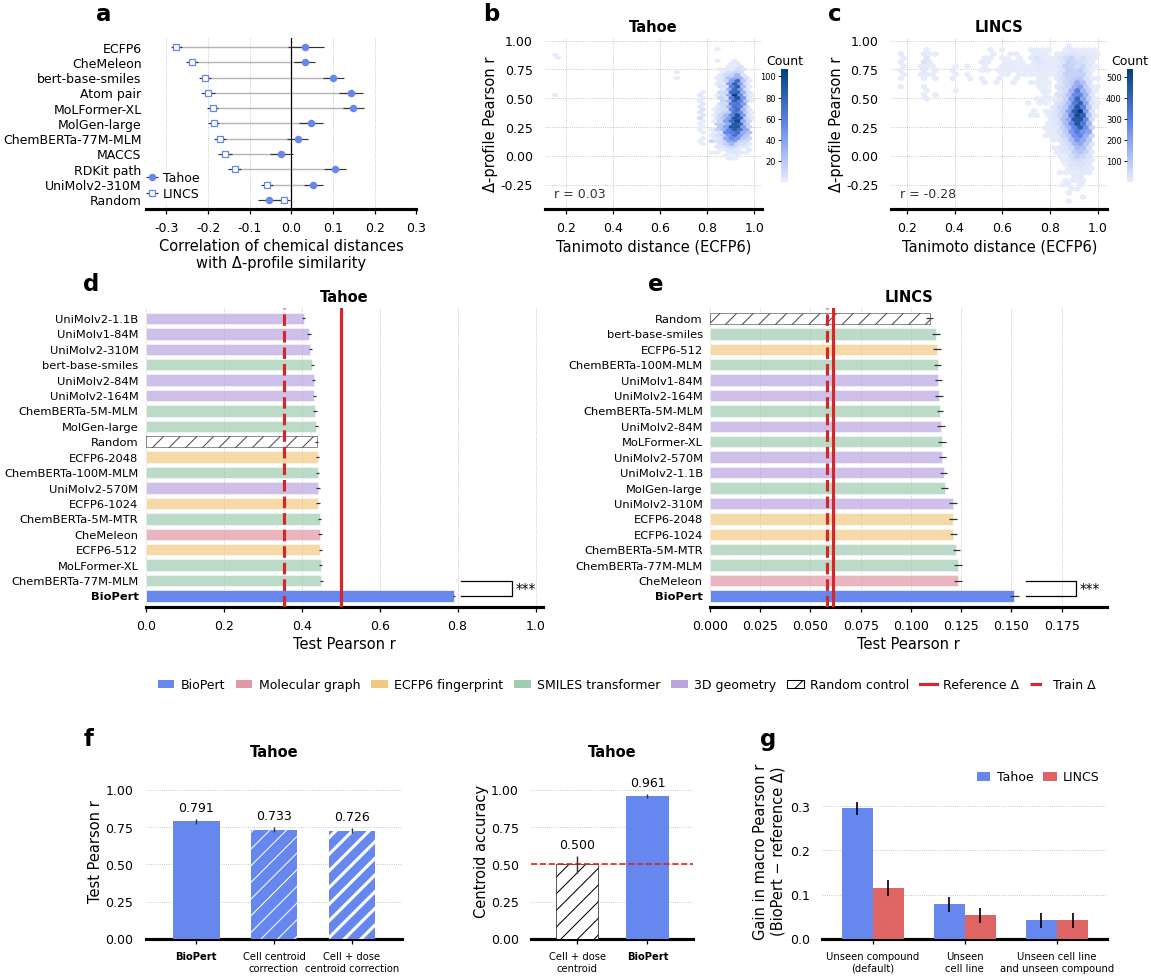

In [138]:
with no_constrained_layout():
    fig = plt.figure(figsize=(DOUBLE_COL, 6.6))
    outer = fig.add_gridspec(
        2, 1, height_ratios=[2.75, 0.85], hspace=0.42,
        left=0.075, right=0.965, top=0.965, bottom=0.055,
    )
    grid = outer[0].subgridspec(
        2, 3, height_ratios=[1.0, 1.75], width_ratios=[1.25, 1.0, 1.0],
        hspace=0.42, wspace=0.55,
    )

    ax_a = fig.add_subplot(grid[0, 0])
    n_metrics = len(corr_df)
    y_a = np.arange(n_metrics)
    for yi, metric in enumerate(corr_df.index):
        ax_a.plot([corr_df.loc[metric, "tahoe"], corr_df.loc[metric, "lincs"]],
                  [yi, yi], color=GRAY, lw=0.7, alpha=0.6, zorder=1)
    for ds, mk in zip(DATASETS, ("o", "s")):
        r = corr_df[ds]
        ax_a.errorbar(
            r, y_a, xerr=np.vstack([r - ci_lo[ds], ci_hi[ds] - r]), fmt=mk,
            color=(BLUE if ds == "tahoe" else "white"), ms=3.0,
            ecolor="#333333", elinewidth=0.55, capsize=0,
            markeredgecolor=BLUE, markeredgewidth=0.6,
            label=DS_LABELS[ds], zorder=3)
    ax_a.axvline(0, color="black", linewidth=0.6, zorder=1)
    ax_a.set_yticks(y_a)
    ax_a.set_yticklabels([EROW_LABELS.get(c[:-5], c[:-5]) for c in corr_df.index],
                         fontsize=6.0)
    ax_a.set_ylim(-0.6, n_metrics - 0.4)
    ax_a.set_xlim(-0.35, 0.30)
    ax_a.set_xlabel("Correlation of chemical distances\nwith Δ-profile similarity")
    ax_a.legend(loc="lower left", fontsize=6.0, frameon=True, framealpha=0.85,
                edgecolor="none", handletextpad=0.3, borderpad=0.25,
                labelspacing=0.25, bbox_to_anchor=(-0.03, 0.01))
    style_hbar_ax(ax_a)
    ax_a.tick_params(axis="y", labelleft=True, labelright=False, length=0, pad=2)

    hex_axes = []
    for i, ds in enumerate(DATASETS):
        ax = fig.add_subplot(grid[0, i + 1], sharey=hex_axes[0] if hex_axes else None)
        hex_axes.append(ax)
        df = sar[ds]
        hb = ax.hexbin(df[f"{EROW_PIN}_dist"], df["pearson"], gridsize=34,
                       cmap=HEXBIN_CMAP, mincnt=1, linewidths=0.2)
        _p = ax.get_position()
        cax = fig.add_axes([_p.x1 + 0.018, _p.y0 + 0.16 * _p.height,
                            0.006, 0.66 * _p.height])
        cb = fig.colorbar(hb, cax=cax)
        cb.ax.set_title("Count", fontsize=6.0, pad=2)
        cb.ax.yaxis.set_ticks_position("left")
        cb.ax.tick_params(labelsize=4, length=1.5, width=0.4, pad=1.0)
        cb.outline.set_visible(False)
        ax.set_title(DS_LABELS[ds], fontweight="bold")
        ax.set_xlabel("Tanimoto distance (ECFP6)")
        r, _ = pearsonr(df[f"{EROW_PIN}_dist"], df["pearson"])
        ax.text(0.04, 0.05, f"r = {r:.2f}", transform=ax.transAxes,
                ha="left", va="bottom", fontsize=6, color="#333333")
        style_ax(ax, grid="both")
        ax.set_ylabel("Δ-profile Pearson r", labelpad=1)
        ax.tick_params(axis="y", labelleft=True)

    rank = grid[1, :].subgridspec(1, 2, wspace=0.42)
    ax_d, ax_e = fig.add_subplot(rank[0]), fig.add_subplot(rank[1])
    for ax, ds in ((ax_d, "Tahoe"), (ax_e, "LINCS")):
        representation_panel(ax, ds, draw_bracket=True, x_from_zero=True)

    bottom = outer[1].subgridspec(1, 3, width_ratios=[1.35, 0.85, 1.5], wspace=0.55)
    ax_f1, ax_f2, ax_g = (fig.add_subplot(bottom[i]) for i in range(3))

    for ax, group, styles, labels in (
        (ax_f1, "Pearson r",
         [dict(facecolor=BLUE, edgecolor="none", hatch=None, linewidth=0, hatch_linewidth=0.5),
          dict(facecolor=BLUE, edgecolor="white", hatch="///", linewidth=0, hatch_linewidth=0.5),
          dict(facecolor=BLUE, edgecolor="white", hatch="///", linewidth=0, hatch_linewidth=1.5)],
         ["BioPert", "Cell centroid\ncorrection", "Cell + dose\ncentroid correction"]),
        (ax_f2, "Systema centroid accuracy",
         [dict(facecolor="white", edgecolor="black", hatch="///", linewidth=0.3, hatch_linewidth=0.5),
          dict(facecolor=BLUE, edgecolor="none", hatch=None, linewidth=0, hatch_linewidth=0.5)],
         ["Cell + dose\ncentroid", "BioPert"]),
    ):
        rows = fig2_systema.query("group == @group")
        x = np.arange(len(rows), dtype=float)
        for xi, (_, row), sty in zip(x, rows.iterrows(), styles):
            ax.bar(xi, row.estimate, width=0.6, **sty,
                   yerr=[[row.estimate - row.lo], [row.hi - row.estimate]],
                   error_kw=dict(ecolor="#333333", elinewidth=0.7, capsize=0, zorder=6),
                   zorder=3)
            ax.text(xi, row.hi + 0.03, f"{row.estimate:.3f}", ha="center",
                    va="bottom", fontsize=6.0, zorder=7)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=4.8)
        for t in ax.get_xticklabels():
            if t.get_text() == "BioPert":
                t.set_fontweight("bold")
        ax.set_xlim(-0.65, len(rows) - 0.35)
        ax.set_ylim(0, 1.18)
        ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_title("Tahoe", fontweight="bold")
        ax.set_ylabel("Test Pearson r" if group == "Pearson r"
                      else "Centroid accuracy", labelpad=1)
        style_ax(ax, grid="y")
    ax_f2.axhline(0.5, ls="--", lw=0.8, color=RED, zorder=5)

    regimes_g = ("Q2", "Q3", "Q4")
    centers_g = np.arange(len(regimes_g), dtype=float)
    width_g = 0.34
    for ds, (off, color) in {"Tahoe": (-width_g / 2, BLUE),
                             "LINCS": (width_g / 2, "#df6464")}.items():
        for center, q in zip(centers_g, regimes_g):
            row = fig2_generalization.query("dataset == @ds and quadrant == @q").iloc[0]
            ax_g.bar(center + off, row.estimate, width=width_g, color=color,
                     edgecolor="none", linewidth=0,
                     yerr=[[row.estimate - row.lo], [row.hi - row.estimate]],
                     error_kw=dict(ecolor="black", elinewidth=0.8, capsize=0), zorder=3)
    ax_g.set_xticks(centers_g)
    ax_g.set_xticklabels(["Unseen compound\n(default)", "Unseen\ncell line",
                          "Unseen cell line\nand unseen compound"], fontsize=4.8)
    ax_g.set_xlim(-0.55, 2.55)
    ax_g.set_ylim(0, fig2_generalization["hi"].max() * 1.28)
    ax_g.set_ylabel("Gain in macro Pearson r\n(BioPert − reference Δ)")
    ax_g.legend(handles=[Patch(facecolor=BLUE, label="Tahoe"),
                         Patch(facecolor="#df6464", label="LINCS")],
                loc="upper right", fontsize=6.0, frameon=False, ncol=2,
                handlelength=1.1, columnspacing=0.8, borderaxespad=0.2)
    style_ax(ax_g, grid="y")

    handles = [
        Patch(facecolor=BLUE, label="BioPert"),
        Patch(facecolor=MODEL_TYPE_COLORS["Molecular graph MPNN"], label="Molecular graph"),
        Patch(facecolor=MODEL_TYPE_COLORS["Morgan fingerprint"], label="ECFP6 fingerprint"),
        Patch(facecolor=MODEL_TYPE_COLORS["SMILES transformer"], label="SMILES transformer"),
        Patch(facecolor=MODEL_TYPE_COLORS["3D geometry (UniMol)"], label="3D geometry"),
        Patch(facecolor="white", edgecolor="black", hatch="///", label="Random control"),
        Line2D([0], [0], color=RED, ls="-", lw=1.5, label="Reference Δ"),
        Line2D([0], [0], color=RED, ls="--", lw=1.5, label="Train Δ"),
    ]
    d_pos, e_pos, f_pos = ax_d.get_position(), ax_e.get_position(), ax_f1.get_position()
    fig.legend(handles=handles, loc="center",
               bbox_to_anchor=((d_pos.x0 + e_pos.x1) / 2, (d_pos.y0 + f_pos.y1) / 2),
               ncol=8, fontsize=6, frameon=False, handlelength=1.3, columnspacing=0.9)

    label_panels([ax_a], letters=["a"], dx=-24, dy=6)
    label_panels(hex_axes + [ax_d, ax_e, ax_f1, ax_g],
                 letters=["b", "c", "d", "e", "f", "g"], dx=-30, dy=6)
    save_figure(fig, "fig2_representations_sar")
    plt.show()


In [139]:
# Number of distinct cell lines, compounds, and response samples behind Fig. 2g.
# Q4 is restricted to the strict intersection of explicitly test-held-out
# cell lines and explicitly test-held-out compounds; validation identities
# that enter the union test split are excluded. Compounds are counted by the
# canonical SMILES used to define the compound split.
FIG2_QUADRANT_LABEL = {
    "Q2": "Unseen compound, seen cell line",
    "Q3": "Unseen cell line, seen compound",
    "Q4": "Unseen cell line, unseen compound",
}

fig2_split_count_rows = []
for _ds, _ek in FIG2_CELLLINE_EXP.items():
    _quadrants = results.load_quadrants(_ek, split="test")
    # Q3 can enter the union test split only through an explicitly test-held-out
    # cell line, so it identifies the test cell-line set without val contamination.
    _test_cell_lines = set(
        _quadrants.loc[_quadrants["quadrant"] == "Q3", "cell_line"]
    )
    # The ordinary compound-only experiment uses the same pinned compound split.
    _test_compounds = set(
        results.load_perobs_single(FIG2_DEFAULT_EXP[_ds], split="test")["smiles"]
    )

    for _q in ("Q2", "Q3", "Q4"):
        _group = _quadrants.loc[_quadrants["quadrant"] == _q].copy()
        if _q == "Q4":
            _group = _group.loc[
                _group["cell_line"].isin(_test_cell_lines)
                & _group["smiles"].isin(_test_compounds)
            ]
        fig2_split_count_rows.append({
            "Dataset": _ds,
            "Split": _q,
            "Generalization regime": FIG2_QUADRANT_LABEL[_q],
            "Cell lines": _group["cell_line"].nunique(),
            "Compounds (canonical SMILES)": _group["smiles"].nunique(),
            "Samples": len(_group),
        })

fig2_split_counts = pd.DataFrame(fig2_split_count_rows)
display(fig2_split_counts.style.hide(axis="index").format(thousands=","))


Dataset,Split,Generalization regime,Cell lines,Compounds (canonical SMILES),Samples
Tahoe,Q2,"Unseen compound, seen cell line",35,56,"5,834"
Tahoe,Q3,"Unseen cell line, seen compound",7,283,"5,678"
Tahoe,Q4,"Unseen cell line, unseen compound",7,56,"1,104"
LINCS,Q2,"Unseen compound, seen cell line",167,"1,151","34,641"
LINCS,Q3,"Unseen cell line, seen compound",20,"1,648","12,759"
LINCS,Q4,"Unseen cell line, unseen compound",20,325,"2,063"


In [140]:
res.to_csv("results.csv", index=False)

## Figure 3 — Replicate reproducibility and sequencing depth govern achievable performance

*(Merged from the former Fig 3 "Reproducibility and depth" and Fig 5 "Replicate reproducibility of the LINCS data". The inter-plate ridge group and the standalone bimodality panel are dropped — the latter is now folded into (a). Figs 6–7 renumber down to 5–6.)*

**(a)** Pairwise replicate Pearson r for LINCS, as three independent rows (each peak-normalised to 1, own baseline; black tick = median). Fill colour encodes each distribution's **mean** Pearson on the `coolwarm_r` ramp (red = low agreement, blue = high) — the same ramp (e) uses, so colour carries one meaning across the figure. **Top:** all absolute-profile pairs pooled — treated and untreated, intra- and inter-plate (median 0.92; the four levels are tightly clustered, 0.90–0.94, and pooling is sample-size weighted so inter-plate treated pairs dominate the count). **Middle:** intra-plate Δ (0.45), stacked by condition — its high-r mode is driven almost entirely by the most concentrated / longest exposures (20 µM × 24 h, then 10 µM × 24 h). **Bottom:** inter-plate Δ (0.07). The **Δ-profile** — the quantity CAP predicts — is far noisier than the raw profiles it is built from, and noisier still across plates; that bounds achievable accuracy (c). The x-range is cropped at −0.3, which omits <0.4% of inter-plate pairs. **(b)** *Pending rebuild.* The variance decomposition previously shown here used a custom estimator and has been withdrawn. It is being recomputed with `variancePartition` (lme4 REML), the reference implementation, and will report the share of expression variance attributable to each design factor for absolute profiles (top) and Δ profiles (bottom) in both datasets. The axes are held blank in the meantime. **(c)** Model accuracy rises with test-condition replicate reproducibility (per-bin mean ± 95% bootstrap CI). **(d)** Test-condition count per bin — the sample size behind (c); shares (c)'s x-axis. **(e)** Test Pearson vs the *training-set* reproducibility filter, with the fixed test set split into 0.1-wide reproducibility bins (colour): pruning training data hurts at every level, while the most reproducible conditions stay robust. **(f)** Tahoe: accuracy vs the sequencing depth of the target (treated) profile being predicted, overlaid with the best-fitting saturating curve (chosen by adjusted R²) — a measurement-quality-of-the-output effect, distinct from (c–e), which vary the reproducibility/filtering of the training data.

Reproducibility panels (a, b) adapted from `repro.ipynb`.

In [141]:
# Figure 3 (a) data — LINCS replicate reproducibility (ridge levels).
# Panel (b) data — variancePartition (lme4 REML) variance decomposition
REPRO_LEVELS = ["untrt_intra", "trt_intra", "delta_intra",
                "untrt_inter", "trt_inter", "delta_inter"]
repro_lincs = {lvl: pd.read_csv(f"{REPRO_DIR['lincs']}/repro_{lvl}.csv",
                                usecols=["pearson"])["pearson"].dropna().values
               for lvl in REPRO_LEVELS}
delta_lincs = pd.read_csv(f"{REPRO_DIR['lincs']}/repro_delta_intra.csv",
                          usecols=["cell_line", "plate", "drug", "dose", "time", "pearson"])

print("LINCS repro levels:", {k: len(v) for k, v in repro_lincs.items()})


BATCH_DIR = f"{BASE}/batch_effects"
VP_FACTORS = ["cell_line", "plate", "drug"]#, "dose", "time"]

def load_vp(prefix):
    fs = sorted(glob.glob(f"{BATCH_DIR}/{prefix}_vp_chunk*.csv"))
    merged = f"{BATCH_DIR}/{prefix}_vp_per_gene.csv"
    if fs:
        df = pd.concat([pd.read_csv(f) for f in fs], ignore_index=True)
    elif os.path.exists(merged):
        df = pd.read_csv(merged)
    else:
        return None
    return df.rename(columns={"cell_line:plate": "plate",
                              "Residuals": "residual"}).sort_values("gene")

vp = {k: v for k in ["tahoe", "lincs", "tahoe_delta", "lincs_delta"]
      if (v := load_vp(k)) is not None}

print("Fig 3b variance decomposition:",
      {k: f"{len(d)} genes" for k, d in vp.items()})


LINCS repro levels: {'untrt_intra': 540425, 'trt_intra': 114970, 'delta_intra': 114970, 'untrt_inter': 39743, 'trt_inter': 1603752, 'delta_inter': 1603752}
Fig 3b variance decomposition: {'tahoe': '964 genes', 'lincs': '978 genes', 'tahoe_delta': '964 genes', 'lincs_delta': '978 genes'}


In [142]:
REPRO_OBS_CACHE = "cache_repro_obs.parquet"
if os.path.exists(REPRO_OBS_CACHE) and not RECOMPUTE_STATS:
    repro_obs = pd.read_parquet(REPRO_OBS_CACHE)
else:
    repro_obs = (
        pd.read_csv(REPRO_CSV["lincs"], usecols=["cell_line", "drug", "dose", "time", "pearson"])
        .groupby(["cell_line", "drug", "dose", "time"], as_index=False)["pearson"]
        .mean()
        .rename(columns={"pearson": "repro_pearson"})
    )
    repro_obs.to_parquet(REPRO_OBS_CACHE, index=False)
lincs_test = results.load_perobs_single("lincs_default_config", split="test")
lincs_test = lincs_test.merge(repro_obs, on=["cell_line", "drug", "dose", "time"], how="left")
lincs_m = lincs_test.dropna(subset=["repro_pearson"]).copy()

bin_edges = np.arange(np.floor(lincs_m["repro_pearson"].min() * 10) / 10, 1.001, 0.1)
lincs_m["repro_bin"] = pd.cut(lincs_m["repro_pearson"], bins=bin_edges)
binned = (
    lincs_m.groupby("repro_bin")
    .agg(model_pearson=("pearson", "mean"),
         repro_center=("repro_pearson", "mean"),
         n=("pearson", "size"))
    .dropna()
)
binned = binned[binned["n"] >= 20]
binned["bin_mid"] = [iv.mid for iv in binned.index]
_ci = {b: fst.bootstrap_ci_mean(g["pearson"].to_numpy(), n_boot=N_BOOT,
                                ci=CI, seed=STAT_SEED)
       for b, g in lincs_m.groupby("repro_bin", observed=True)}
binned["lo"] = [_ci[b][1] for b in binned.index]
binned["hi"] = [_ci[b][2] for b in binned.index]
slope, intercept = np.polyfit(binned["bin_mid"], binned["model_pearson"], 1)
pred = slope * binned["bin_mid"] + intercept
r2 = 1 - ((binned["model_pearson"] - pred) ** 2).sum() / \
        ((binned["model_pearson"] - binned["model_pearson"].mean()) ** 2).sum()
sp_repro = fst.spearman_ci(lincs_m["repro_pearson"], lincs_m["pearson"],
                           n_boot=N_BOOT, ci=CI, seed=STAT_SEED)
lf_repro = fst.linfit_ci(binned["bin_mid"], binned["model_pearson"],
                         n_boot=N_BOOT, ci=CI, seed=STAT_SEED)
print(f"Fig 3c: {len(binned)} bins, binned R² = {r2:.3f}")
print(f"Fig 3c: per-condition Spearman ρ = {sp_repro['rho']:.3f} "
      f"[{sp_repro['lo']:.3f}, {sp_repro['hi']:.3f}], p = {sp_repro['p']:.1e}, "
      f"n = {sp_repro['n']:,}")
print(f"Fig 3c: binned-slope β = {lf_repro['slope']:.3f} "
      f"[{lf_repro['lo']:.3f}, {lf_repro['hi']:.3f}]")


Fig 3c: 13 bins, binned R² = 0.924
Fig 3c: per-condition Spearman ρ = 0.392 [0.381, 0.404], p = 0.0e+00, n = 29,547
Fig 3c: binned-slope β = 0.649 [0.552, 0.814]


In [143]:
cbin_edges = np.arange(-0.4, 1.0001, 0.1)
repro_obs["rbin"] = pd.cut(repro_obs["repro_pearson"], bins=cbin_edges)

thresh_keys = [("none", "lincs_default_config")]
for t in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    key = "lincs_default_repro_0" if t == 0.0 else f"lincs_default_repro_{t}"
    thresh_keys.append((f"{t:.1f}", key))

bin_perf, bin_count = {}, None
stash = {}
for lbl, key in thresh_keys:
    t = results.load_perobs_single(key, split="test")
    t = t.merge(repro_obs[["cell_line", "drug", "dose", "time", "rbin"]],
                on=["cell_line", "drug", "dose", "time"], how="left")
    g = t.dropna(subset=["rbin"]).groupby("rbin", observed=True)["pearson"]
    bin_perf[lbl] = g.mean()
    if bin_count is None:
        bin_count = g.size()
    if lbl in ("none", "0.5"):
        stash[lbl] = t.dropna(subset=["rbin"])
perf_c = pd.DataFrame(bin_perf)
keep = bin_count[bin_count >= 100].index
perf_c = perf_c.loc[perf_c.index.isin(keep)].sort_index()
bin_mid = pd.Series([iv.mid for iv in perf_c.index], index=perf_c.index)
print(f"Fig 3e: {len(perf_c)} reproducibility bins (n>=100):")
print(perf_c.round(3))

repro_filter_tests = {}
if {"none", "0.5"} <= stash.keys():
    bands = list(perf_c.index)
    rows = []
    for b in bands:
        a = stash["none"][stash["none"]["rbin"] == b]
        c = stash["0.5"][stash["0.5"]["rbin"] == b]
        rows.append(fst.paired_delta(
            a, c, metric="pearson", n_boot=N_BOOT, seed=STAT_SEED))
    padj = fst.bh_fdr([r["p"] for r in rows])
    for b, r, pa in zip(bands, rows, padj):
        r["p_adj"] = float(pa)
        repro_filter_tests[b] = r
    n_worse = sum(1 for r in repro_filter_tests.values()
                  if r["p_adj"] < 0.05 and r["mean_diff"] > 0)
    print(f"Fig 3e: θ=0.5 filter significantly LOWERS test Pearson vs no filter "
          f"in {n_worse}/{len(bands)} bands (paired Wilcoxon, BH p<0.05).")

Fig 3e: 11 reproducibility bins (n>=100):
                    none    0.0    0.1    0.2    0.3    0.4    0.5
rbin                                                              
(-0.3, -0.2]       0.078  0.072  0.067  0.046  0.047  0.038  0.033
(-0.2, -0.1]       0.072  0.059  0.045  0.041  0.025  0.019  0.017
(-0.1, -1.11e-16]  0.062  0.056  0.043  0.032  0.025  0.020  0.018
(-1.11e-16, 0.1]   0.099  0.095  0.074  0.056  0.044  0.034  0.032
(0.1, 0.2]         0.179  0.184  0.164  0.142  0.123  0.101  0.092
(0.2, 0.3]         0.298  0.311  0.314  0.286  0.269  0.241  0.215
(0.3, 0.4]         0.414  0.431  0.434  0.427  0.423  0.390  0.356
(0.4, 0.5]         0.519  0.531  0.538  0.548  0.548  0.522  0.482
(0.5, 0.6]         0.601  0.613  0.622  0.621  0.644  0.628  0.602
(0.6, 0.7]         0.642  0.662  0.670  0.677  0.702  0.688  0.674
(0.7, 0.8]         0.697  0.712  0.707  0.710  0.739  0.745  0.724
Fig 3e: θ=0.5 filter significantly LOWERS test Pearson vs no filter in 8/11 bands (pair

In [144]:
from scipy.optimize import curve_fit

tahoe_def_d = results.load_perobs_single("tahoe_default_config", split="test")
cl_depth = (
    tahoe_def_d.groupby("cell_line")
    .agg(pearson=("pearson", "mean"), umis=("total_umis", "mean"))
    .dropna()
)
sp_depth = fst.spearman_ci(cl_depth["umis"], cl_depth["pearson"],
                           n_boot=N_BOOT, ci=CI, seed=STAT_SEED)

_xd = cl_depth["umis"].to_numpy() / 1e6
_yd = cl_depth["pearson"].to_numpy()
def _adj_r2(y, yhat, k):
    n = len(y)
    r2 = 1 - np.sum((y - yhat) ** 2) / np.sum((y - y.mean()) ** 2)
    return r2, 1 - (1 - r2) * (n - 1) / (n - k - 1)
_CANDIDATES = [
    ("logarithmic",      "y = a + b·ln x",      lambda x, a, b: a + b * np.log(x),            [0.7, 0.05]),
    ("square-root",      "y = a + b·√x",        lambda x, a, b: a + b * np.sqrt(x),           [0.6, 0.05]),
    ("power",            "y = a + b·xᶜ",        lambda x, a, b, c: a + b * np.power(x, c),    [0.6, 0.1, 0.5]),
    ("saturating exp.",  "y = c − a·e^(−x/τ)",  lambda x, c, a, tau: c - a * np.exp(-x / tau), [0.85, 0.2, 1.0]),
    ("Michaelis–Menten", "y = c + a·x/(k+x)",   lambda x, c, a, k: c + a * x / (k + x),       [0.6, 0.25, 1.0]),
]
_fits = []
for _name, _eqn, _f, _p0 in _CANDIDATES:
    try:
        _popt, _ = curve_fit(_f, _xd, _yd, p0=_p0, maxfev=20000)
        _r2, _adj = _adj_r2(_yd, _f(_xd, *_popt), len(_popt))
        _fits.append(dict(name=_name, eqn=_eqn, f=_f, popt=_popt, r2=_r2, adj_r2=_adj))
    except Exception:
        pass
_fits.sort(key=lambda d: -d["adj_r2"])
depth_fit = _fits[0]

print(f"Fig 3f: {len(cl_depth)} depth pts")
print("Fig 3f depth→accuracy curve fits (sorted by adjusted R²):")
for d in _fits:
    print(f"   {d['name']:18s} {d['eqn']:22s} R²={d['r2']:.3f}  adjR²={d['adj_r2']:.3f}")
print(f"   → chosen: {depth_fit['name']} ({depth_fit['eqn']}), "
      f"R²={depth_fit['r2']:.3f}, adjR²={depth_fit['adj_r2']:.3f}")


Fig 3f: 47 depth pts
Fig 3f depth→accuracy curve fits (sorted by adjusted R²):
   Michaelis–Menten   y = c + a·x/(k+x)      R²=0.949  adjR²=0.945
   logarithmic        y = a + b·ln x         R²=0.940  adjR²=0.938
   power              y = a + b·xᶜ           R²=0.940  adjR²=0.936
   saturating exp.    y = c − a·e^(−x/τ)     R²=0.937  adjR²=0.932
   square-root        y = a + b·√x           R²=0.833  adjR²=0.826
   → chosen: Michaelis–Menten (y = c + a·x/(k+x)), R²=0.949, adjR²=0.945


saved final_figures/fig3_reproducibility_performance.{pdf,png}


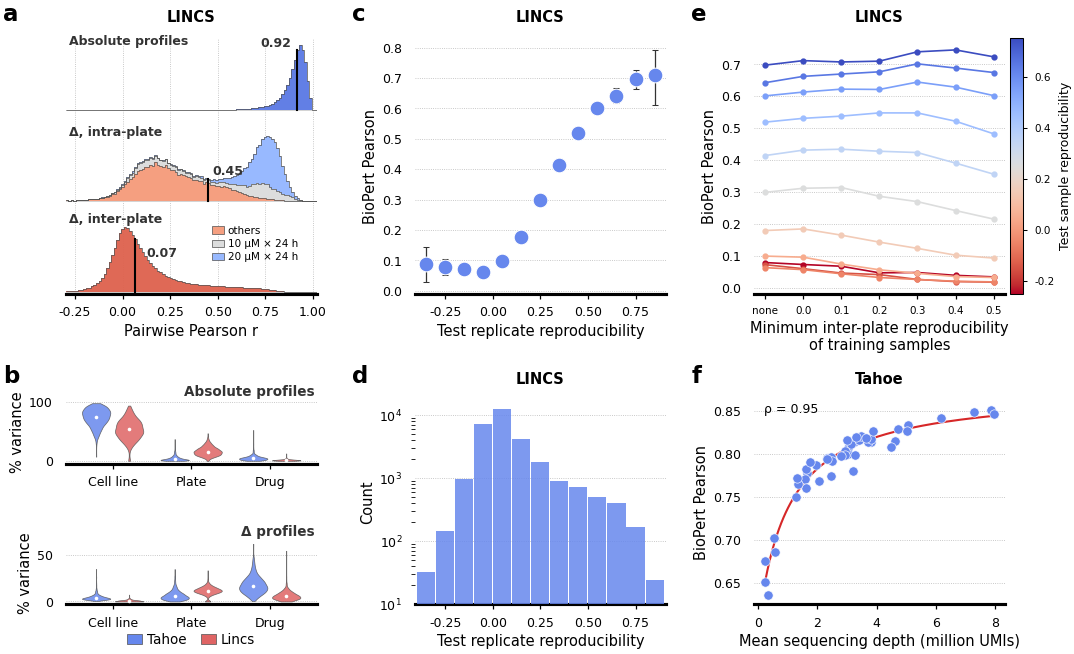

In [145]:
fig = plt.figure(figsize=(DOUBLE_COL, 4.4))
TITLE_PAD = 8            # lift titles clear of the tallest curves
gs = fig.add_gridspec(4, 3, width_ratios=[1, 1.0, 1.0], height_ratios=[3, 3, 2, 2])

ax_a = fig.add_subplot(gs[0:2, 0])  # intra-plate ridge, Δ split by condition
# (b) is two stacked rows of the same flat grid: absolute profiles over deltas.
ax_b = fig.add_subplot(gs[2, 0])    # variance decomposition, absolute (pending)
ax_b2 = fig.add_subplot(gs[3, 0])   # variance decomposition, delta (pending)
ax_c = fig.add_subplot(gs[0:2, 1])  # accuracy vs test reproducibility
ax_d = fig.add_subplot(gs[2:4, 1])  # bin counts (shares x with c)
ax_e = fig.add_subplot(gs[0:2, 2])  # training-filter sweep
ax_f = fig.add_subplot(gs[2:4, 2])  # Tahoe depth

X_LIM = (-0.3, 1.02)
edges = np.linspace(*X_LIM, 100)
ROW_H, ROW_GAP = 1.0, 0.4
row_step = ROW_H + ROW_GAP

def _row_base(i):
    return i * row_step

_repro_cmap = mpl.colormaps["coolwarm_r"]
_repro_norm = mpl.colors.Normalize(vmin=0.0, vmax=1.0)
def _mean_color(vals):
    return _repro_cmap(_repro_norm(float(np.mean(vals))))

_raw_all = np.concatenate([repro_lincs[f"{p}_{pl}"]
                           for p in ("untrt", "trt") for pl in ("intra", "inter")])
_rc, _ = np.histogram(_raw_all, bins=edges)
_rh = _rc / _rc.max()
_yb = _row_base(2)
ax_a.stairs(_yb + _rh, edges, baseline=_yb, fill=True, color=_mean_color(_raw_all),
            alpha=0.95, lw=0, zorder=3)
ax_a.stairs(_yb + _rh, edges, baseline=None, fill=False, color="#555555",
            lw=0.35, zorder=5)
_rmed = np.median(_raw_all)
_rb = int(np.clip(np.searchsorted(edges, _rmed) - 1, 0, len(_rh) - 1))
ax_a.plot([_rmed, _rmed], [_yb, _yb + _rh[_rb]], color="black", lw=1.0, zorder=6)
ax_a.text(_rmed - 0.03, _yb + _rh[_rb], f"{_rmed:.2f}", color="#333333", fontsize=6,
          ha="right", va="bottom", fontweight="bold", zorder=7)

_m10 = (delta_lincs["dose"] == "10 uM") & (delta_lincs["time"] == "24 h")
_m20 = (delta_lincs["dose"] == "20 uM") & (delta_lincs["time"] == "24 h")
DELTA_GROUPS = [(~(_m10 | _m20), "others"),
                (_m10, "10 µM × 24 h"),
                (_m20, "20 µM × 24 h")]
_gvals = [delta_lincs[m]["pearson"].dropna().values for m, _ in DELTA_GROUPS]
_gcols = [_mean_color(v) for v in _gvals]
_counts = [np.histogram(v, bins=edges)[0] for v in _gvals]
_scale = np.sum(_counts, axis=0).max()
_yb = _row_base(1)
_cum = np.full_like(_counts[0], _yb, dtype=float)
for cnt, col in zip(_counts, _gcols):
    top = _cum + cnt / _scale
    ax_a.stairs(top, edges, baseline=_cum, fill=True, color=col, alpha=1.0,
                lw=0, zorder=4)
    ax_a.stairs(top, edges, baseline=None, fill=False, color="#555555",
                lw=0.35, zorder=5)
    _cum = top
_dintra = delta_lincs["pearson"].dropna().values
_dmed = np.median(_dintra)
_db = int(np.clip(np.searchsorted(edges, _dmed) - 1, 0, len(_cum) - 1))
ax_a.plot([_dmed, _dmed], [_yb, _cum[_db]], color="black", lw=1.0, zorder=6)
ax_a.text(_dmed + 0.02, _cum[_db] + 0.02, f"{_dmed:.2f}", color="#333333", fontsize=6,
          ha="left", va="bottom", fontweight="bold", zorder=7)

_dinter = repro_lincs["delta_inter"]
_ic, _ = np.histogram(_dinter, bins=edges)
_ih = _ic / _ic.max()
_yb = _row_base(0)
ax_a.stairs(_yb + _ih, edges, baseline=_yb, fill=True, color=_mean_color(_dinter),
            alpha=0.95, lw=0, zorder=3)
ax_a.stairs(_yb + _ih, edges, baseline=None, fill=False, color="#555555",
            lw=0.35, zorder=5)
_imed = np.median(_dinter)
_ib = int(np.clip(np.searchsorted(edges, _imed) - 1, 0, len(_ih) - 1))
ax_a.plot([_imed, _imed], [_yb, _yb + _ih[_ib]], color="black", lw=1.0, zorder=6)
ax_a.text(_imed + 0.06, _yb + _ih[_ib] * 0.62, f"{_imed:.2f}", color="#333333", fontsize=6,
          ha="left", va="bottom", fontweight="bold", zorder=7)

for _i, _lab in [(2, "Absolute profiles"), (1, "Δ, intra-plate"), (0, "Δ, inter-plate")]:
    gap = 0.22 if _i == 0 else 0.15
    ax_a.text(X_LIM[0] + 0.02, _row_base(_i) + ROW_H + gap, _lab, fontsize=6,
              fontweight="bold", color="#333333", ha="left", va="top", zorder=8)
for _i in range(3):
    ax_a.axhline(_row_base(_i), color="#cccccc", lw=0.4, zorder=1)

ax_a.set_yticks([])
ax_a.set_xlim(*X_LIM)
ax_a.set_ylim(-0.02, _row_base(2) + ROW_H + 0.10)
ax_a.set_xlabel("Pairwise Pearson r")
ax_a.set_title("LINCS", fontweight="bold", pad=TITLE_PAD)
# cover any distribution. Swatches carry each group's mean-Pearson colour.
ax_a.legend(handles=[Patch(facecolor=c, edgecolor="#555555", linewidth=0.35, label=l)
                     for c, (_m, l) in zip(_gcols, DELTA_GROUPS)],
            loc="lower right", fontsize=5, bbox_to_anchor=(0.95, 0.1),
            title=None, title_fontsize=5, handlelength=1.1,
            handletextpad=0.4, labelspacing=0.3, borderpad=0.3, frameon=False)
style_ax(ax_a, grid="x")

VP_COLORS = {"tahoe": BLUE, "lincs": "#df6464"}
VP_LABELS = {"cell_line": "Cell line", "plate": "Plate", "drug": "Drug",
             "dose": "Dose", "time": "Time"}
VP_OFFSET, VP_WIDTH = 0.21, 0.36

for _ax, _suffix, _row in ((ax_b, "", "Absolute profiles"), (ax_b2, "_delta", "Δ profiles")):
    for _i, _f in enumerate(VP_FACTORS):
        for _ds, _sgn in (("tahoe", -1), ("lincs", +1)):
            _d = vp.get(f"{_ds}{_suffix}")
            if _d is None or _f not in _d:
                continue
            _v = _d[_f].dropna().values
            _pc = _ax.violinplot(_v, positions=[_i + _sgn * VP_OFFSET],
                                 widths=VP_WIDTH, showextrema=False)
            for _b in _pc["bodies"]:
                _b.set_facecolor(VP_COLORS[_ds])
                _b.set_alpha(0.85)
                _b.set_edgecolor("#555555")
                _b.set_linewidth(0.35)
            _ax.scatter([_i + _sgn * VP_OFFSET], [np.median(_v)], s=3,
                        color="white", zorder=4, linewidths=0)
    _ax.set_xticks(range(len(VP_FACTORS)))
    _ax.set_xlim(-0.6, len(VP_FACTORS) - 0.4)
    # _ax.set_ylim(-2, 102)
    _ax.set_ylabel("% variance")
    _ax.text(0.99, 1.25, _row, transform=_ax.transAxes, fontsize=6.5,
             fontweight="bold", color="#333333", ha="right", va="top")
    style_ax(_ax, grid="y")

ax_b.set_xticklabels([VP_LABELS[f] for f in VP_FACTORS], ha="center")
ax_b2.set_xticklabels([VP_LABELS[f] for f in VP_FACTORS], ha="center")
# ax_b.set_title("Variance decomposition", fontweight="bold", pad=TITLE_PAD)
ax_b2.legend(handles=[Patch(facecolor=VP_COLORS[d], edgecolor="#555555",
                           linewidth=0.35, label=d.capitalize())
                     for d in ("tahoe", "lincs")],
            loc="lower center", fontsize=6.5, handlelength=1.1, handletextpad=0.4,
            labelspacing=0.3, borderpad=0.3, frameon=False, ncol=2, bbox_to_anchor=(0.5, -0.8))

# ── (c) performance vs test-condition reproducibility (per-bin mean ± 95% CI) ──
ax_c.errorbar(binned["bin_mid"], binned["model_pearson"],
              yerr=[binned["model_pearson"] - binned["lo"],
                    binned["hi"] - binned["model_pearson"]],
              **{**ERR_KW, "capthick": 0.5})
ax_c.scatter(binned["bin_mid"], binned["model_pearson"], s=50, color=BLUE,
             zorder=3, edgecolor="white", linewidth=0.5)
ax_c.set_ylabel("BioPert Pearson")
ax_c.set_xlabel("Test replicate reproducibility")
ax_c.set_title("LINCS", fontweight="bold", pad=TITLE_PAD)
style_ax(ax_c)

# ── (d) test-condition count per reproducibility bin (log scale) ──
ax_d.bar(binned["bin_mid"], binned["n"], width=0.095, color=BLUE, alpha=0.85, zorder=3)
ax_d.set_yscale("log")
ax_d.set_ylim(10, None)
ax_d.set_xlim(ax_c.get_xlim())
ax_d.set_xlabel("Test replicate reproducibility")
ax_d.set_ylabel("Count")
ax_d.set_title("LINCS", fontweight="bold", pad=TITLE_PAD)
style_ax(ax_d)

# ── (e) test Pearson vs training filter; one line per test-reproducibility bin ──
xpos = np.arange(perf_c.shape[1])
norm = mpl.colors.Normalize(vmin=bin_mid.min(), vmax=bin_mid.max())
cmap = mpl.colormaps["coolwarm_r"]
for b in perf_c.index:
    ax_e.plot(xpos, perf_c.loc[b].values, marker="o", ms=2, lw=0.8,
              color=cmap(norm(bin_mid[b])), zorder=3)
ax_e.set_xticks(xpos)
ax_e.set_xticklabels(perf_c.columns, fontsize=5)
ax_e.set_xlabel("Minimum inter-plate reproducibility\nof training samples")
ax_e.set_ylabel("BioPert Pearson")
ax_e.set_title("LINCS", fontweight="bold", pad=TITLE_PAD)
style_ax(ax_e)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_e, pad=0.02, fraction=0.06)
cbar.set_label("Test sample reproducibility", fontsize=6)
cbar.ax.tick_params(labelsize=5, width=0.5, length=2)
cbar.outline.set_linewidth(0.5)

# ── (f) Tahoe: accuracy vs target sequencing depth + best-fitting saturating curve ──
ax_f.scatter(cl_depth["umis"] / 1e6, cl_depth["pearson"], s=20, color=BLUE,
             alpha=1, **SCATTER_KW)
_xx = np.linspace(_xd.min(), _xd.max(), 200)
ax_f.plot(_xx, depth_fit["f"](_xx, *depth_fit["popt"]), color=RED, lw=1, zorder=2)
ax_f.set_xlabel("Mean sequencing depth (million UMIs)")
ax_f.set_ylabel("BioPert Pearson")
ax_f.set_title("Tahoe", fontweight="bold", pad=TITLE_PAD)
ax_f.text(0.04, 0.99, f"ρ = {sp_depth['rho']:.2f}", transform=ax_f.transAxes,
          va="top", ha="left", fontsize=6, color="black")
style_ax(ax_f)

fig.get_layout_engine().set(wspace=0.07, hspace=0.06)
label_panels([ax_a, ax_b, ax_c, ax_d, ax_e, ax_f], dx=-30, dy=6)
save_figure(fig, "fig3_reproducibility_performance")
plt.show()

In [146]:
vp["tahoe"].describe()

,gene,cell_line,dose,drug,plate,residual
count,964.00000,964.000000,964.000000,964.000000,964.000000,964.000000
mean,481.50000,73.403886,0.120102,5.005194,3.986430,17.484388
std,278.42713,15.019987,0.190006,4.324084,4.353837,10.908625
min,0.00000,7.047062,0.000000,0.039765,0.031839,1.679765
25%,240.75000,64.016743,0.006218,2.186299,1.106775,9.647726
50%,481.50000,75.221964,0.050391,4.176351,2.447317,14.961395
75%,722.25000,84.942615,0.152578,6.439530,5.203430,22.621021
max,963.00000,97.870189,2.101918,52.376920,36.960370,76.849008


In [147]:
vp["tahoe_delta"].describe()

,gene,cell_line,dose,drug,plate,residual
count,964.00000,964.000000,9.640000e+02,964.000000,964.000000,964.000000
mean,481.50000,4.500151,4.499670e-01,17.858287,6.772054,70.419541
std,278.42713,3.207702,6.511374e-01,9.242280,5.164107,11.811792
min,0.00000,0.645949,0.000000e+00,0.537434,0.021248,21.858336
25%,240.75000,2.538653,6.709268e-07,11.177885,3.142234,63.095128
50%,481.50000,3.612851,1.970566e-01,16.343018,5.520661,71.373688
75%,722.25000,5.349743,6.317569e-01,22.880544,8.934354,79.139935
max,963.00000,34.736481,5.138502e+00,61.560530,34.555274,96.946634


In [148]:
vp["lincs"].describe()

,gene,cell_line,plate,dose,drug,time,residual
count,978.000000,978.000000,978.000000,978.000000,9.780000e+02,978.000000,978.000000
mean,488.500000,53.384616,16.579998,0.644797,1.428728e+00,9.626753,18.335107
std,282.468582,17.385915,7.730591,2.862264,1.304573e+00,14.394809,11.411382
min,0.000000,0.000203,0.000075,0.000000,1.032007e-12,0.000000,0.000103
25%,244.250000,41.700139,10.921881,0.033466,6.268126e-01,1.683746,9.931494
50%,488.500000,53.268009,15.746515,0.145074,1.157207e+00,5.050741,15.799371
75%,732.750000,65.650647,21.344588,0.552425,1.927231e+00,12.047413,24.405862
max,977.000000,93.775013,46.896008,83.380519,1.254581e+01,99.999608,71.979844


In [149]:
vp["lincs_delta"].describe()

,gene,cell_line,plate,dose,drug,time,residual
count,978.000000,978.000000,978.000000,978.000000,978.000000,978.000000,978.000000
mean,488.500000,0.951199,11.481432,0.871086,6.217806,12.707083,67.771394
std,282.468582,0.957771,4.555163,2.046021,4.671751,25.442348,21.304128
min,0.000000,0.000000,0.000011,0.000000,0.000005,0.000000,0.000067
25%,244.250000,0.203722,9.373586,0.036887,3.123041,0.000000,63.171754
50%,488.500000,0.773645,11.680897,0.190059,5.517143,0.398062,74.195328
75%,732.750000,1.351589,14.125734,0.754382,8.542244,12.555587,81.282055
max,977.000000,7.301595,33.322120,27.573906,54.144174,99.999916,92.408991


## Figure 4 — Reference-context generalization and mechanistic transfer

**(a)** Per-test-condition accuracy for each reference cell line, Tahoe (A549, PANC-1, A-172, COLO 205). **(b)** Same, LINCS (A549, MCF7, PC3) — the reference barely shifts the distribution in either dataset. The two panels share an x-axis but list their own references: apart from A549 the datasets have no reference cell line in common. **(c)** Tahoe accuracy versus reference–target Δ-response similarity (colour and marker denote the reference cell line). **(d)** LINCS best-by-validation test Pearson for three ways of constructing `delta_ref`: a single fixed draw (default), a fresh resampled replicate at each training epoch, or the average of all replicates. **(e)** For cobimetinib (0.5 μM, 24 h) in the BRAF-V600E melanoma line C32, measured target pathway NES versus either BioPert-predicted C32 NES or measured A549 reference NES across Hallmark and Reactome pathways. Both comparisons use identical axes; darker symbols mark target FDR q ≤ 0.05 and lighter symbols mark 0.05 < q ≤ 0.25. **(f)** Signed ranking scores for established ERK-output genes and a melanocytic MITF–PGC-1α module in measured C32, predicted C32 and measured A549.

The ERK-output module follows the MEK-dependent transcriptional program described by [Pratilas *et al.*](https://doi.org/10.1073/pnas.0900780106), and the MITF–PGC-1α/OXPHOS link follows [Haq *et al.*](https://doi.org/10.1016/j.ccr.2013.02.003). Panel c reports Spearman ρ; full statistics for panels a–d and the pathway concordance values in e are exported in the statistics cell below.

In [150]:
delta_corr = pd.read_csv(
    "/network/scratch/l/lola.lebreton/transcriptomes/results/ref_target_delta_corr.csv")

TAHOE_REF = [  # display, exp_key, ref CVCL
    ("PANC-1", "tahoe_CVCL_0480", "CVCL_0480"),
    ("A-172", "tahoe_CVCL_0131", "CVCL_0131"),
    ("COLO 205", "tahoe_CVCL_0218", "CVCL_0218"),
    ("A549 (default)", "tahoe_default_config", "CVCL_0023"),
]
LINCS_REF = [("A549", "lincs_default_config"),
             ("MCF7", "lincs_MCF7"), ("PC3", "lincs_PC3")]
REF_NAME = {"A549 (default)": "A549", "A-172": "A-172",
            "COLO 205": "COLO 205", "PANC-1": "PANC-1"}

tahoe_perobs = {exp: results.load_perobs_single(exp, split="test")
                for _, exp, _ in TAHOE_REF}
tahoe_box = {disp: tahoe_perobs[exp].groupby("cell_line")["pearson"].mean()
             for disp, exp, _ in TAHOE_REF}
tahoe_raw = {disp: tahoe_perobs[exp]["pearson"].dropna().to_numpy()
             for disp, exp, _ in TAHOE_REF}

lincs_perobs = {exp: results.load_perobs_single(exp, split="test") for _, exp in LINCS_REF}
lincs_box = {disp: lincs_perobs[exp].groupby("cell_line")["pearson"].mean()
             for disp, exp in LINCS_REF}
lincs_raw = {disp: lincs_perobs[exp]["pearson"].dropna().to_numpy()
             for disp, exp in LINCS_REF}

TAHOE_RIDGE_ORDER = ["A549 (default)", "PANC-1", "A-172", "COLO 205"]
LINCS_RIDGE_ORDER = ["A549", "MCF7", "PC3"]

fried_tahoe = fst.friedman_blocked(pd.DataFrame(tahoe_box))
fried_lincs = fst.friedman_blocked(pd.DataFrame(lincs_box))

sim_rows = []
for disp, exp, cvcl in TAHOE_REF:
    perf = tahoe_perobs[exp].groupby("cell_line")["pearson"].mean().rename("test_pearson")
    dd = delta_corr[delta_corr.cl_i == cvcl][["cl_j", "mean_delta_pearson"]]
    m = dd.merge(perf, left_on="cl_j", right_index=True).dropna()
    m["ref_name"] = REF_NAME[disp]
    sim_rows.append(m)
sim = pd.concat(sim_rows, ignore_index=True)
sp_sim = fst.spearman_ci(sim["mean_delta_pearson"], sim["test_pearson"],
                         n_boot=N_BOOT, ci=CI, seed=STAT_SEED)

REF_HANDLING = {"lincs_default_config": "Single draw\n(default)",
                "lincs_resample_ref": "Resample\neach epoch",
                "lincs_average_ref": "Average of\nreplicates"}
RH_CMAP = mcolors.LinearSegmentedColormap.from_list("cap_blue_rh", [LBLUE, BLUE, DBLUE])

rh_best = (results.best_runs[results.best_runs.exp_key.isin(REF_HANDLING)]
           .set_index("exp_key"))
rh_ci = {}
for ek in rh_best.index:
    _o = get_perobs(ek)
    rh_ci[ek] = fst.bootstrap_ci_mean(_o["pearson"].to_numpy(), n_boot=N_BOOT,
                                      ci=CI, seed=STAT_SEED,
                                      cluster_by=_o["cell_line"].to_numpy())

RH_PAIRS = [("lincs_average_ref", "lincs_default_config"),
            ("lincs_resample_ref", "lincs_default_config"),
            ("lincs_average_ref", "lincs_resample_ref")]
rh_tests = {(a, b): fst.paired_delta(get_perobs(a), get_perobs(b),
                                     metric="pearson", n_boot=N_BOOT,
                                     seed=STAT_SEED)
            for a, b in RH_PAIRS if a in rh_best.index and b in rh_best.index}

print(f"Fig 4 data ready: {len(tahoe_box)} Tahoe refs, {len(lincs_box)} LINCS refs, "
      f"{len(sim)} similarity pts, {len(rh_best)} ref-handling arms.")


Fig 4 data ready: 4 Tahoe refs, 3 LINCS refs, 188 similarity pts, 3 ref-handling arms.


In [151]:

TAHOE_ROWS = [("A549 (default)", "A549"), ("PANC-1", "PANC-1"),
              ("A-172", "A-172"), ("COLO 205", "COLO 205")]
LINCS_ROWS = [("A549", "A549"), ("MCF7", "MCF7"), ("PC3", "PC3")]

X_LIM_A = (-0.5, 1.0)
edges = np.linspace(*X_LIM_A, 41)
centers = (edges[:-1] + edges[1:]) / 2
width = edges[1] - edges[0]
row_h = 1.05

def _ridge_row(ax, vals, y_base, color):
    """One histogram ridge at y_base."""
    counts, _ = np.histogram(vals, bins=edges)
    heights = counts / counts.max()
    ax.bar(centers, heights, width=width * 0.92, bottom=y_base, color=color, alpha=0.85,
           edgecolor="white", linewidth=0.3, zorder=3)
    avg = float(np.mean(vals))
    avg_bin = int(np.clip(np.searchsorted(edges, avg) - 1, 0, len(heights) - 1))
    ax.plot([avg, avg], [y_base, y_base + heights[avg_bin]], color="black", lw=1.1, zorder=5)

def _ridge_panel(ax, rows, raw_dict, color, title):
    """`rows` is [(key in raw_dict, row label)], bottom-to-top. Every row is drawn,
    so panels with different reference counts stay evenly spaced."""
    for i, (key, row) in enumerate(rows):
        y_base = i * row_h
        ax.axhline(y_base, color="#cccccc", lw=0.4, zorder=1)
        _ridge_row(ax, raw_dict[key], y_base, color)
        ax.text(X_LIM_A[0], y_base + 0.08, row, fontsize=6, va="bottom", ha="left")
    ax.set_yticks([])
    ax.set_ylim(0, (len(rows) - 1) * row_h + 1.05)
    ax.set_xlim(*X_LIM_A)
    ax.set_xlabel("Test Pearson")
    ax.set_title(title, fontweight="bold")
    style_ax(ax, grid="x")

RHO_XY = (0.04, 0.99)
Y_LIM = (0.6, 0.87)


In [152]:
# Figure 4 statistics (for the manuscript text / caption). Collected here rather than
# drawn on the panels: a/b show the distributions, c displays only ρ.
def _median_spread(box_dict, drop=()):
    w = pd.DataFrame({k: v for k, v in box_dict.items()
                      if k not in drop}).dropna(how="any")
    med = w.median()
    return float(med.max() - med.min()), w.shape[0]

spread_tahoe, n_tahoe = _median_spread(tahoe_box)
spread_lincs, n_lincs = _median_spread(lincs_box)

print("Figure 4 — statistics for the paper")
print("=" * 72)
print("(a, b) Reference cell line — Friedman test, blocked by target cell line (paired).")
print(f"   Tahoe: χ²={fried_tahoe['stat']:.2f}, {fst.fmt_p(fried_tahoe['p'])}, "
      f"Kendall W={fried_tahoe['W']:.3f}  "
      f"({fried_tahoe['k']} refs × {fried_tahoe['n_blocks']} lines); "
      f"median-accuracy spread across refs = {spread_tahoe:.3f}")
print(f"   LINCS: χ²={fried_lincs['stat']:.2f}, {fst.fmt_p(fried_lincs['p'])}, "
      f"Kendall W={fried_lincs['W']:.3f}  "
      f"({fried_lincs['k']} refs × {fried_lincs['n_blocks']} lines); "
      f"median-accuracy spread across refs = {spread_lincs:.3f}")
print("   → significance reflects consistency across many paired lines, not a")
print("     large effect (spread ≤ 0.03 in test Pearson).")
print("-" * 72)
print("(c) Accuracy vs reference–target Δ-profile similarity — Spearman")
print(f"   ρ = {sp_sim['rho']:.3f}  95% CI [{sp_sim['lo']:.3f}, {sp_sim['hi']:.3f}], "
      f"{fst.fmt_p(sp_sim['p'])}, n = {sp_sim['n']}")
print("-" * 72)
print("(d) LINCS reference handling — best-by-val run per experiment (selection metric: "
      "val Spearman ρ):")
for ek in REF_HANDLING:
    if ek not in rh_best.index:
        continue
    m, lo, hi = rh_ci[ek]
    print(f"   {REF_HANDLING[ek].replace(chr(10), ' '):24s}"
          f"  val ρ={rh_best.loc[ek, 'val_spearman']:.4f}"
          f"  test r={m:.4f} [{lo:.4f}, {hi:.4f}]"
          f"  lr={rh_best.loc[ek, 'lr']:.2e} bs={rh_best.loc[ek, 'batch_size']:.0f}"
          f" pca={rh_best.loc[ek, 'n_pca_expr']:.0f} ep={rh_best.loc[ek, 'selected_epoch']:.0f}")
print("   Paired differences in test Pearson r (shared pinned test split):")
for (a, b), d in rh_tests.items():
    la = REF_HANDLING[a].replace(chr(10), " ")
    lb = REF_HANDLING[b].replace(chr(10), " ")
    print(f"     {la:24s} - {lb:24s} Δ={d['mean_diff']:+.4f} "
          f"[{d['lo']:+.4f}, {d['hi']:+.4f}]  p={d['p']:.2e}  n={d['n_pairs']}")
print("   Read with care: the paired test is over ~40k test conditions, so it")
print("   detects differences far smaller than the spread the hyperparameter search")
print("   itself produces across trials. Quote Δ and its CI, not p. One run per arm:")
print("   no seed replicates, so every interval here is sampling variability over")
print("   the test set, not training variability.")


Figure 4 — statistics for the paper
(a, b) Reference cell line — Friedman test, blocked by target cell line (paired).
   Tahoe: χ²=111.05, p = 7e-24, Kendall W=0.841  (4 refs × 44 lines); median-accuracy spread across refs = 0.028
   LINCS: χ²=61.56, p = 4e-14, Kendall W=0.172  (3 refs × 179 lines); median-accuracy spread across refs = 0.020
   → significance reflects consistency across many paired lines, not a
     large effect (spread ≤ 0.03 in test Pearson).
------------------------------------------------------------------------
(c) Accuracy vs reference–target Δ-profile similarity — Spearman
   ρ = 0.793  95% CI [0.721, 0.847], p = 6e-42, n = 188
------------------------------------------------------------------------
(d) LINCS reference handling — best-by-val run per experiment (selection metric: val Spearman ρ):
   Single draw (default)     val ρ=0.1752  test r=0.1515 [0.1411, 0.1716]  lr=7.08e-05 bs=32 pca=128 ep=30
   Resample each epoch       val ρ=0.1821  test r=0.1557 [0.14

<!-- Case-01 pathway inputs for Figure 4e,f. -->

In [153]:
from pathlib import Path
from scipy.stats import spearmanr

PATHWAY_CASE_ROOT = Path(
    "/network/scratch/l/lola.lebreton/transcriptomes/results/tahoe_pathway_cases"
)
CASE_ID = "case_01"
GSEA_ROOT = PATHWAY_CASE_ROOT / "gsea"

case01_meta = (
    pd.read_csv(GSEA_ROOT / "shortlist_annotated.csv")
    .loc[lambda x: x["case_id"].eq(CASE_ID)]
    .squeeze()
)
assert case01_meta["cell_name"] == "C32"
assert case01_meta["drug"] == "Cobimetinib"

# Align the three complete gene profiles by symbol. These are the signed
# treated-minus-DMSO values used to rank genes for preranked GSEA.
case01_gene_profiles = pd.concat(
    {profile: pd.read_csv(GSEA_ROOT / f"{CASE_ID}_{profile}_ranking.csv")
              .set_index("gene")["score"]
     for profile in ["target", "prediction", "reference"]},
    axis=1, join="inner",
)
assert case01_gene_profiles.shape == (19020, 3)
assert case01_gene_profiles.notna().all().all()

# One row per pathway, with all three NES/FDR pairs aligned one-to-one.
_case01_long = (
    pd.read_csv(GSEA_ROOT / "pathway_results.csv")
    .loc[lambda x: x["case_id"].eq(CASE_ID)]
)
case01_pathways = None
for _profile in ["target", "prediction", "reference"]:
    _part = (
        _case01_long.loc[_case01_long["profile"].eq(_profile),
                         ["collection", "pathway", "nes", "fdr_q"]]
        .rename(columns={"nes": f"{_profile}_nes",
                         "fdr_q": f"{_profile}_fdr_q"})
    )
    case01_pathways = (_part if case01_pathways is None else
                       case01_pathways.merge(
                           _part, on=["collection", "pathway"],
                           how="inner", validate="one_to_one"))

assert len(case01_pathways) == 1227
assert case01_pathways.groupby("collection")["pathway"].nunique().to_dict() == {
    "hallmark": 50, "reactome": 1177
}
assert case01_pathways.filter(regex="_(nes|fdr_q)$").notna().all().all()
case01_pathways["target_fdr_class"] = np.select(
    [case01_pathways["target_fdr_q"].le(0.05),
     case01_pathways["target_fdr_q"].le(0.25)],
    ["q ≤ 0.05", "0.05 < q ≤ 0.25"],
    default="q > 0.25",
)

_pathway_metric_rows = []
for _scope in ["all", "hallmark", "reactome"]:
    _frame = (case01_pathways if _scope == "all" else
              case01_pathways.loc[case01_pathways["collection"].eq(_scope)])
    for _profile, _label in [("prediction", "BioPert prediction"),
                             ("reference", "A549 reference")]:
        _x = _frame["target_nes"].to_numpy()
        _y = _frame[f"{_profile}_nes"].to_numpy()
        _pathway_metric_rows.append({
            "collection": _scope, "comparison": _label,
            "spearman_rho": spearmanr(_x, _y).statistic,
            "mae": np.mean(np.abs(_x - _y)), "n_pathways": len(_frame),
        })
case01_pathway_metrics = pd.DataFrame(_pathway_metric_rows)

CASE01_MODULES = {
    "ERK-output genes":
        ["DUSP6", "ETV1", "ETV4", "ETV5", "SPRY2", "SPRY4",
         "SPRED1", "SPRED2"],
    "Melanocytic / MITF–PGC-1α":
        ["MITF", "DCT", "TYR", "MLANA", "TYRP1", "PPARGC1A",
         "GLUD1", "IDH1"],
}
_module_lookup = {gene: module for module, genes in CASE01_MODULES.items()
                  for gene in genes}
_gene_order = [gene for genes in CASE01_MODULES.values() for gene in genes]
case01_module_scores = (
    case01_gene_profiles.loc[_gene_order]
    .rename_axis("gene").reset_index()
    .melt(id_vars="gene", var_name="profile", value_name="signed_rank_score")
)
case01_module_scores["module"] = case01_module_scores["gene"].map(_module_lookup)
case01_module_scores["gene_order"] = case01_module_scores["gene"].map(
    {gene: i for i, gene in enumerate(_gene_order)}
)
assert len(case01_module_scores) == 16 * 3
assert case01_module_scores["signed_rank_score"].notna().all()

display(case01_pathway_metrics.round(3))


,collection,comparison,spearman_rho,mae,n_pathways
0,all,BioPert prediction,0.875,0.352,1227
1,all,A549 reference,0.375,0.837,1227
2,hallmark,BioPert prediction,0.900,0.317,50
3,hallmark,A549 reference,0.518,0.877,50
4,reactome,BioPert prediction,0.874,0.353,1177
5,reactome,A549 reference,0.368,0.835,1177


saved final_figures/fig4_generalization.{pdf,png}


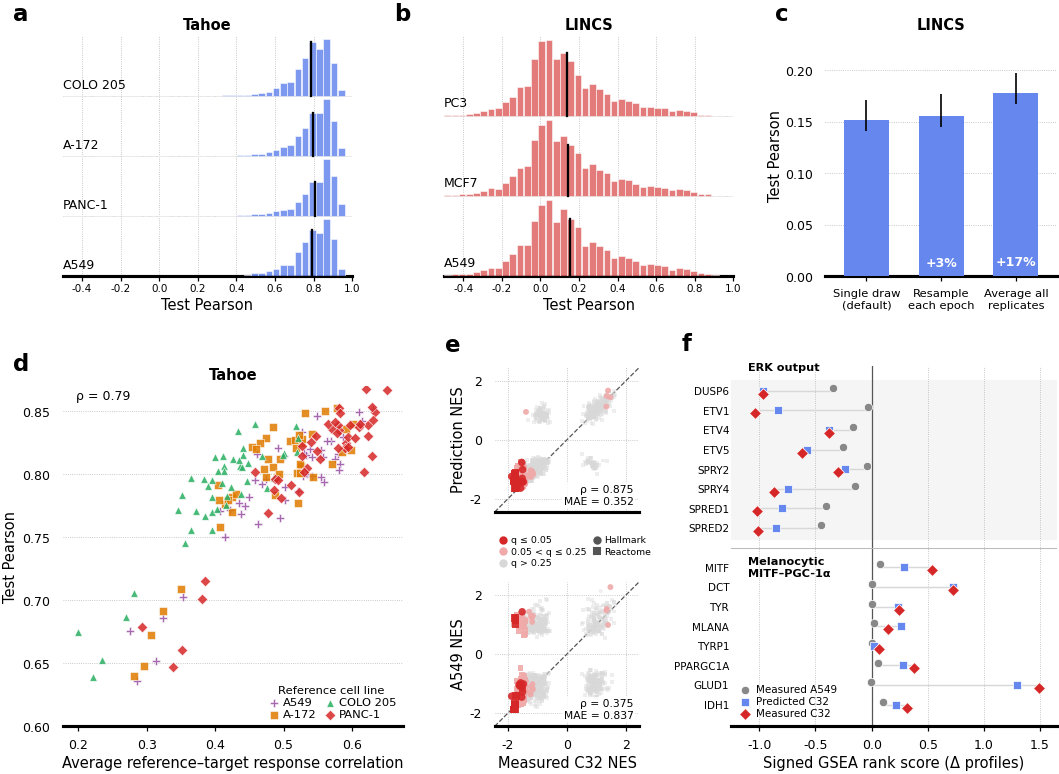

In [154]:

with no_constrained_layout():
    fig = plt.figure(figsize=(DOUBLE_COL, 5.2))
    outer = fig.add_gridspec(
        2, 1, height_ratios=[0.80, 1.20], hspace=0.30,
        left=0.065, right=0.985, top=0.955, bottom=0.070,
    )
    top = outer[0].subgridspec(
        1, 3, width_ratios=[1.0, 1.0, 0.80], wspace=0.34,
    )
    bottom = outer[1].subgridspec(
        1, 3, width_ratios=[1.41, 0.60, 1.35], wspace=0.34,
    )
    pathway_grid = bottom[1].subgridspec(2, 1, hspace=0.45)

    axa = fig.add_subplot(top[0, 0])
    axb = fig.add_subplot(top[0, 1])
    axd = fig.add_subplot(top[0, 2])
    axc = fig.add_subplot(bottom[0, 0])
    axe_pred = fig.add_subplot(pathway_grid[0, 0])
    axe_ref = fig.add_subplot(pathway_grid[1, 0])
    axf = fig.add_subplot(bottom[0, 2])
    fig.set_layout_engine("none")

fig.set_layout_engine("none")

# (a, b) Compact reference-cell-line distributions.
_ridge_panel(axa, TAHOE_ROWS, tahoe_raw, BLUE, "Tahoe")
_ridge_panel(axb, LINCS_ROWS, lincs_raw, "#df6464", "LINCS")
for _ax in (axa, axb):
    _ax.tick_params(axis="x", labelsize=5.0, pad=1)
    _ax.xaxis.label.set_size(7.0)

# (d) Accuracy versus reference–target response similarity.
for _rname in ["A549", "A-172", "COLO 205", "PANC-1"]:
    _s = sim.loc[sim["ref_name"].eq(_rname)]
    axc.scatter(
        _s["mean_delta_pearson"], _s["test_pearson"], s=13,
        color=REF_COLORS[_rname], marker=REF_MARKERS[_rname], alpha=0.85,
        label=_rname, **SCATTER_KW,
    )
axc.set_xlabel("Average reference–target response correlation", fontsize=7.0)
axc.set_ylabel("Test Pearson", fontsize=7.0)
axc.set_title("Tahoe", fontweight="bold")
axc.text(*RHO_XY, f"ρ = {sp_sim['rho']:.2f}", transform=axc.transAxes,
         va="top", ha="left", fontsize=6, color="black")
axc.legend(loc="lower right", fontsize=5.5, title="Reference cell line",
           title_fontsize=5.5, ncol=2, handletextpad=0.2,
           columnspacing=0.55, labelspacing=0.18, borderpad=0.25)
axc.set_ylim(*Y_LIM)
axc.set_box_aspect(1.0)
axc.set_anchor("S")
style_ax(axc)

# (c) Reference handling, styled to match Figure 2g.
_rh_keys = [ek for ek in ["lincs_default_config", "lincs_resample_ref",
                          "lincs_average_ref"] if ek in rh_best.index]
_rh_x = np.arange(len(_rh_keys), dtype=float)
_rh_vals = np.array([rh_ci[ek][0] for ek in _rh_keys])
_rh_err = np.vstack([
    [_rh_vals[i] - rh_ci[ek][1] for i, ek in enumerate(_rh_keys)],
    [rh_ci[ek][2] - _rh_vals[i] for i, ek in enumerate(_rh_keys)],
])
axd.bar(
    _rh_x, _rh_vals, width=0.60, color=BLUE, edgecolor="none", linewidth=0,
    yerr=_rh_err,
    error_kw=dict(ecolor="black", elinewidth=0.8, capsize=0), zorder=3,
)
axd.set_xticks(_rh_x)
axd.set_xticklabels(["Single draw\n(default)", "Resample\neach epoch",
                     "Average all\nreplicates"], fontsize=5.5)
axd.set_xlim(-0.55, len(_rh_keys) - 0.45)
axd.set_ylim(0, max(rh_ci[ek][2] for ek in _rh_keys) * 1.18)
axd.set_ylabel("Test Pearson", labelpad=1, fontsize=7.0)
axd.set_title("LINCS", fontweight="bold")
style_ax(axd, grid="y")
_rh_base = _rh_vals[0]
for _xi, _value in zip(_rh_x[1:], _rh_vals[1:]):
    _pct = 100 * (_value - _rh_base) / _rh_base
    axd.text(_xi, _value * 0.04, f"+{_pct:.0f}%", ha="center",
             va="bottom", fontsize=6.0, fontweight="bold",
             color="white", zorder=6)

# (e) Identically scaled pathway-concordance scatters.
_fdr_colors = {"q > 0.25": "#d8d8d8",
               "0.05 < q ≤ 0.25": "#efaaa9", "q ≤ 0.05": RED}
_fdr_sizes = {"q > 0.25": 3.5, "0.05 < q ≤ 0.25": 8,
              "q ≤ 0.05": 13}
_collection_markers = {"hallmark": "o", "reactome": "s"}
_path_lim = (-2.45, 2.45)

def _fig4_pathway_scatter(ax, profile, show_xlabel):
    for _fdr_class in ["q > 0.25", "0.05 < q ≤ 0.25", "q ≤ 0.05"]:
        for _collection in ["reactome", "hallmark"]:
            _frame = case01_pathways.loc[
                case01_pathways["target_fdr_class"].eq(_fdr_class)
                & case01_pathways["collection"].eq(_collection)
            ]
            ax.scatter(
                _frame["target_nes"], _frame[f"{profile}_nes"],
                s=_fdr_sizes[_fdr_class],
                marker=_collection_markers[_collection],
                facecolor=_fdr_colors[_fdr_class], edgecolor="none",
                alpha=0.42 if _fdr_class == "q > 0.25" else 0.9,
                rasterized=True,
                zorder=2 if _fdr_class == "q > 0.25" else 3,
            )
    ax.plot(_path_lim, _path_lim, color="#555555", ls="--", lw=0.6, zorder=1)
    _comparison = ("BioPert prediction" if profile == "prediction"
                   else "A549 reference")
    _metric = case01_pathway_metrics.loc[
        case01_pathway_metrics["collection"].eq("all")
        & case01_pathway_metrics["comparison"].eq(_comparison)
    ].iloc[0]
    ax.text(0.96, 0.04,
            f"ρ = {_metric['spearman_rho']:.3f}\nMAE = {_metric['mae']:.3f}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=5.2,
            bbox={"facecolor": "white", "edgecolor": "none",
                  "alpha": 0.82, "pad": 0.8}, zorder=5)
    ax.set(xlim=_path_lim, ylim=_path_lim,
           xlabel="Measured C32 NES" if show_xlabel else "",
           ylabel="Prediction NES" if profile == "prediction" else "A549 NES")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([-2, 0, 2])
    ax.set_yticks([-2, 0, 2])
    style_ax(ax, grid="both")

_fig4_pathway_scatter(axe_pred, "prediction", False)
_fig4_pathway_scatter(axe_ref, "reference", True)
axe_ref.set_anchor("S")
axe_pred.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
_pathway_legend = [
    Line2D([], [], marker="o", ls="none", color=RED,
           label="q ≤ 0.05", ms=3.0),
    Line2D([], [], marker="o", ls="none", color="#efaaa9",
           label="0.05 < q ≤ 0.25", ms=3.0),
    Line2D([], [], marker="o", ls="none", color="#d8d8d8",
           label="q > 0.25", ms=3.0),
    Line2D([], [], marker="o", ls="none", color="#555555",
           label="Hallmark", ms=3.0),
    Line2D([], [], marker="s", ls="none", color="#555555",
           label="Reactome", ms=2.8),
]
axe_ref.legend(
    handles=_pathway_legend, loc="lower center",
    bbox_to_anchor=(0.55, 1.05), ncol=2, fontsize=4.5, frameon=False,
    handletextpad=0.2, columnspacing=0.50, labelspacing=0.25,
)

# (f) Signed ranking scores for the prespecified mechanistic genes.
_gene_y = {gene: i if i < 8 else i + 1 for i, gene in enumerate(_gene_order)}
_profile_style = {
    "reference": ("Measured A549", GRAY, "o", -0.15),
    "prediction": ("Predicted C32", BLUE, "s", 0.0),
    "target": ("Measured C32", RED, "D", 0.15),
}
for _gene in _gene_order:
    _frame = case01_module_scores.loc[case01_module_scores["gene"].eq(_gene)]
    axf.plot(
        [_frame["signed_rank_score"].min(), _frame["signed_rank_score"].max()],
        [_gene_y[_gene], _gene_y[_gene]], color="#d8d8d8", lw=0.7, zorder=1,
    )
for _profile, (_label, _color, _marker, _offset) in _profile_style.items():
    _frame = case01_module_scores.loc[
        case01_module_scores["profile"].eq(_profile)
    ]
    axf.scatter(
        _frame["signed_rank_score"],
        _frame["gene"].map(_gene_y) + _offset,
        s=16, color=_color, marker=_marker, label=_label,
        edgecolor="white", linewidth=0.35, zorder=3,
    )
axf.axvline(0, color="#555555", lw=0.6, zorder=1)
axf.axhspan(-0.55, 7.55, color="#f5f5f5", zorder=0)
axf.axhline(8.0, color="#bbbbbb", lw=0.5)
axf.set_yticks([_gene_y[g] for g in _gene_order], _gene_order)
axf.tick_params(axis="y", labelsize=5.0, pad=1)
axf.set_xlim(-1.25, 1.65)
axf.set_ylim(17.1, -1.25)
axf.set_xlabel("Signed GSEA rank score (Δ profiles)")
axf.text(-1.1, -1.2, "ERK output", fontsize=5.4,
         fontweight="bold", va="center")
axf.text(-1.1, 9, "Melanocytic\nMITF–PGC-1α", fontsize=5.4,
         fontweight="bold", va="center")
axf.legend(loc="lower left", ncol=1, fontsize=5.0,
           labelspacing=0.20, frameon=False)
style_hbar_ax(axf)

fs.panel_label(axa, "a", dx=-24, dy=5)
fs.panel_label(axb, "b", dx=-24, dy=5)
fs.panel_label(axc, "d", dx=-24, dy=5)
fs.panel_label(axd, "c", dx=-24, dy=5)
fs.panel_label(axe_pred, "e", dx=-24, dy=5)
fs.panel_label(axf, "f", dx=-24, dy=5)
for _ext in ("pdf", "png"):
    # Matplotlib re-attaches the global constrained-layout engine after a
    # save; disable it again so both exports preserve this manual grid.
    fig.set_layout_engine("none")
    fig.savefig(os.path.join("final_figures", f"fig4_generalization.{_ext}"))
print("saved final_figures/fig4_generalization.{pdf,png}")
plt.show()


## Supplementary figures

### Suppl. — Complete variance partition

Per-gene variance components from `variancePartition` (lme4 REML) for absolute and DMSO-subtracted Δ profiles. Violins show the distribution across genes, vertical lines the interquartile range, white points and labels the median. Every fitted component is shown. Tahoe has a single time point, so a time component is not estimable and is marked *n/a* rather than zero. Components sum to 100% for every gene.

saved final_figures/figS_variance_partition_full.{pdf,png}


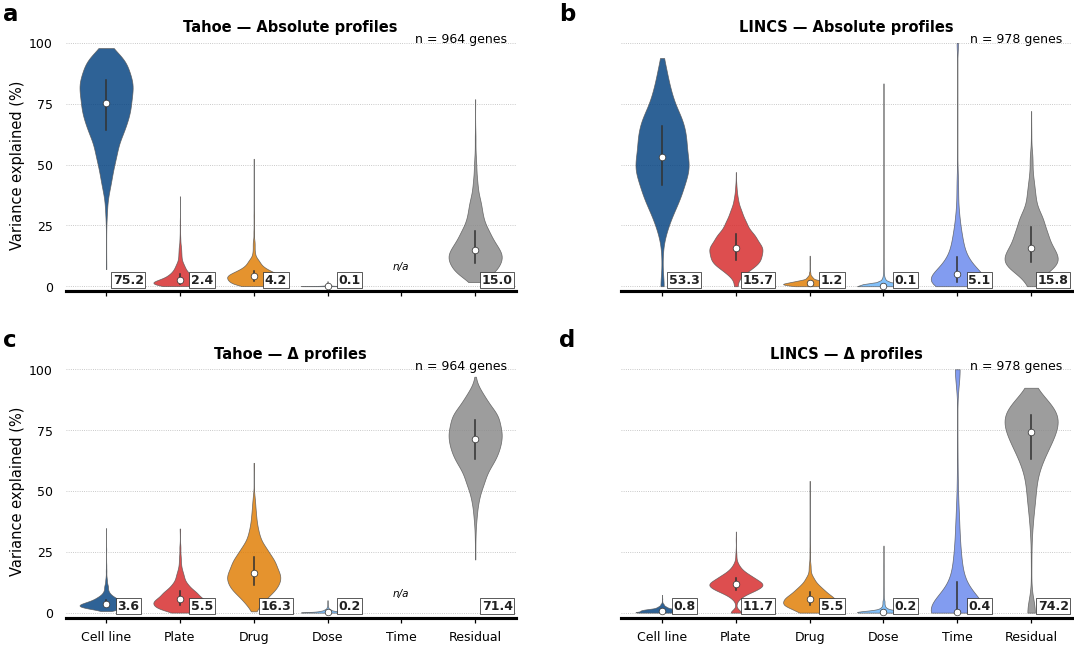

In [155]:
# Complete per-gene variancePartition results underlying Fig. 3b.
VP_FACTORS_FULL = ["cell_line", "plate", "drug", "dose", "time", "residual"]
VP_FULL_LABELS = {"cell_line": "Cell line", "plate": "Plate",
                  "drug": "Drug", "dose": "Dose",
                  "time": "Time", "residual": "Residual"}
VP_FULL_COLORS = {"cell_line": DBLUE, "plate": RED, "drug": ORANGE,
                  "dose": LBLUE, "time": BLUE, "residual": GRAY}
VP_FULL_PANELS = [
    ("tahoe", "Tahoe", "Absolute profiles"),
    ("lincs", "LINCS", "Absolute profiles"),
    ("tahoe_delta", "Tahoe", "Δ profiles"),
    ("lincs_delta", "LINCS", "Δ profiles"),
]

fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL, 4.35),
                         sharex=True, sharey=True)
vp_full_rows = []
for ax, (key, dataset, profile_type) in zip(axes.ravel(), VP_FULL_PANELS):
    d = vp[key].rename(columns={"Residuals": "residual"})
    present = [f for f in VP_FACTORS_FULL if f in d.columns]
    # The fitted fractions must constitute a complete partition for every gene.
    _sums = d[present].sum(axis=1).to_numpy()
    assert np.all(np.isfinite(d[present].to_numpy()))
    assert np.allclose(_sums, 100.0, atol=1e-6)

    for i, factor in enumerate(VP_FACTORS_FULL):
        if factor not in d.columns:
            ax.text(i, 6, "n/a", ha="center", va="bottom", fontsize=5,
                    color="black", fontstyle="italic")
            vp_full_rows.append(dict(
                dataset=dataset, profile_type=profile_type, factor=factor,
                n_genes=d["gene"].nunique(), available=False,
                q25=np.nan, median=np.nan, q75=np.nan, mean=np.nan))
            continue

        values = d[factor].dropna().to_numpy()
        q25, median, q75 = np.quantile(values, [0.25, 0.50, 0.75])
        parts = ax.violinplot(values, positions=[i], widths=0.72,
                              showextrema=False)
        body = parts["bodies"][0]
        body.set_facecolor(VP_FULL_COLORS[factor])
        body.set_alpha(0.82)
        body.set_edgecolor("#555555")
        body.set_linewidth(0.35)
        ax.plot([i, i], [q25, q75], color="#333333", lw=0.75, zorder=4)
        ax.scatter([i], [median], s=10, facecolor="white",
                   edgecolor="#333333", linewidth=0.35, zorder=5)
        _label_y = median + 4.0 if median <= 92 else median - 4.0
        _label_va = "bottom" if median <= 92 else "top"
        ax.text(i + 0.3, 0.01, f"{median:.1f}", ha="center", va=_label_va,
                fontsize=6, fontweight="bold", color="#222222", zorder=6,
                bbox={"facecolor": "white", "edgecolor": "#222222",
                      "linewidth": 0.35, "pad": 0.8})
        vp_full_rows.append(dict(
            dataset=dataset, profile_type=profile_type, factor=factor,
            n_genes=d["gene"].nunique(), available=True, q25=q25,
            median=median, q75=q75, mean=np.mean(values)))

    ax.set_title(f"{dataset} — {profile_type}", fontweight="bold")
    ax.text(0.98, 1.02, f"n = {d['gene'].nunique():,} genes",
            transform=ax.transAxes, ha="right", va="top", fontsize=6,
            color="black")
    ax.set_xticks(range(len(VP_FACTORS_FULL)))
    ax.set_xticklabels([VP_FULL_LABELS[f] for f in VP_FACTORS_FULL],
                       ha="center")
    ax.set_xlim(-0.55, len(VP_FACTORS_FULL) - 0.45)
    ax.set_ylim(-2, 102)
    ax.set_yticks([0, 25, 50, 75, 100])
    style_ax(ax, grid="y")

for ax in axes[:, 0]:
    ax.set_ylabel("Variance explained (%)")
vp_full_summary = pd.DataFrame(vp_full_rows)
label_panels(axes.ravel(), dx=-30, dy=6)
fig.get_layout_engine().set(wspace=0.08, hspace=0.10)
save_figure(fig, "figS_variance_partition_full")
plt.show()

### Suppl. — Absolute-profile replicate reproducibility

Absolute-profile pairwise Pearson distributions decomposed by treatment status (rows) and whether replicate profiles were measured within or across plates (columns). Each distribution is peak-normalized independently, as in Fig. 3a; the black tick and label mark the median. Axes are identical across datasets.

saved final_figures/figS_absolute_reproducibility_grid.{pdf,png}


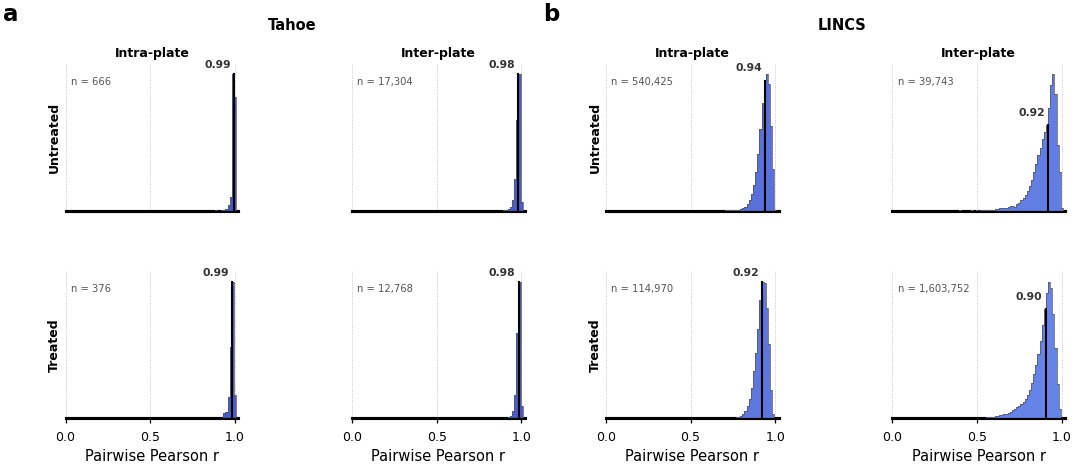

In [156]:
# Absolute-profile reproducibility: 2 × 2 treatment/plate decomposition per dataset.
ABS_REPRO_LEVELS = ["untrt_intra", "untrt_inter",
                    "trt_intra", "trt_inter"]
abs_repro = {}
abs_repro_rows = []
for _ds in DATASETS:
    for _level in ABS_REPRO_LEVELS:
        if _ds == "lincs" and _level in repro_lincs:
            _values = repro_lincs[_level]
        else:
            _values = pd.read_csv(
                f"{REPRO_DIR[_ds]}/repro_{_level}.csv",
                usecols=["pearson"],
            )["pearson"].dropna().to_numpy()
        assert len(_values) > 0 and np.isfinite(_values).all()
        abs_repro[(_ds, _level)] = _values
        abs_repro_rows.append(dict(
            dataset=DS_LABELS[_ds], treatment=("Untreated" if _level.startswith("untrt") else "Treated"),
            plate_scope=("Intra-plate" if _level.endswith("intra") else "Inter-plate"),
            n_pairs=len(_values), mean=np.mean(_values),
            q25=np.quantile(_values, 0.25), median=np.median(_values),
            q75=np.quantile(_values, 0.75)))
abs_repro_summary = pd.DataFrame(abs_repro_rows)

_abs_xlim = (0.0, 1.02)
_abs_edges = np.linspace(*_abs_xlim, 82)
_abs_cmap = mpl.colormaps["coolwarm_r"]
_abs_norm = mpl.colors.Normalize(vmin=0.0, vmax=1.0)

fig = plt.figure(figsize=(DOUBLE_COL, 3.15))
_outer = fig.add_gridspec(1, 2, left=0.07, right=0.985, top=0.90,
                              bottom=0.16, wspace=0.25)
abs_repro_axes = {}
for _j, _ds in enumerate(DATASETS):
    _inner = _outer[0, _j].subgridspec(2, 2, hspace=0.24, wspace=0.18)
    _axs = np.array([[fig.add_subplot(_inner[_r, _c]) for _c in range(2)]
                     for _r in range(2)])
    abs_repro_axes[_ds] = _axs
    for _r, _treatment in enumerate(["untrt", "trt"]):
        for _c, _plate_scope in enumerate(["intra", "inter"]):
            ax = _axs[_r, _c]
            _level = f"{_treatment}_{_plate_scope}"
            _values = abs_repro[(_ds, _level)]
            _counts, _ = np.histogram(_values, bins=_abs_edges)
            _height = _counts / _counts.max()
            _color = _abs_cmap(_abs_norm(float(np.mean(_values))))
            ax.stairs(_height, _abs_edges, baseline=0, fill=True,
                      color=_color, alpha=0.95, lw=0, zorder=3)
            ax.stairs(_height, _abs_edges, baseline=None, fill=False,
                      color="#555555", lw=0.35, zorder=4)
            _median = float(np.median(_values))
            _bin = int(np.clip(np.searchsorted(_abs_edges, _median) - 1,
                               0, len(_height) - 1))
            _median_h = max(float(_height[_bin]), 0.16)
            ax.plot([_median, _median], [0, _median_h],
                    color="black", lw=1.0, zorder=5)
            ax.text(_median - 0.018, min(_median_h + 0.06, 1.03),
                    f"{_median:.2f}", ha="right", va="bottom",
                    fontsize=5.2, fontweight="bold", color="#333333")
            ax.text(0.03, 0.91, f"n = {len(_values):,}",
                    transform=ax.transAxes, ha="left", va="top",
                    fontsize=4.8, color="#555555")
            ax.set_xlim(*_abs_xlim)
            ax.set_ylim(0, 1.08)
            ax.set_yticks([])
            if _r == 0:
                ax.set_title("Intra-plate" if _c == 0 else "Inter-plate",
                             fontsize=6, fontweight="bold")
            if _c == 0:
                ax.set_ylabel("Untreated" if _r == 0 else "Treated",
                              fontsize=6, fontweight="bold")
            if _r == 0:
                ax.tick_params(axis="x", which="both",
                               bottom=False, labelbottom=False)
            else:
                ax.set_xlabel("Pairwise Pearson r")
            style_ax(ax, grid="x")

    _x0 = min(ax.get_position().x0 for ax in _axs.ravel())
    _x1 = max(ax.get_position().x1 for ax in _axs.ravel())
    fig.text((_x0 + _x1) / 2, 0.955, DS_LABELS[_ds], ha="center", va="top",
             fontsize=7, fontweight="bold")
    fs.panel_label(_axs[0, 0], "ab"[_j], dx=-30, dy=18)

save_figure(fig, "figS_absolute_reproducibility_grid")
plt.show()

### Suppl. — Metric robustness

The representation ranking is metric-independent: the same ordering holds under Spearman ρ (**a, b**) and L2 (lower = better; **c, d**). Error bars are 95% bootstrap CIs. Representations are the dose/time-encoded (`gate`) arms, as in Fig 3.

saved final_figures/figS_metric_robustness.{pdf,png}


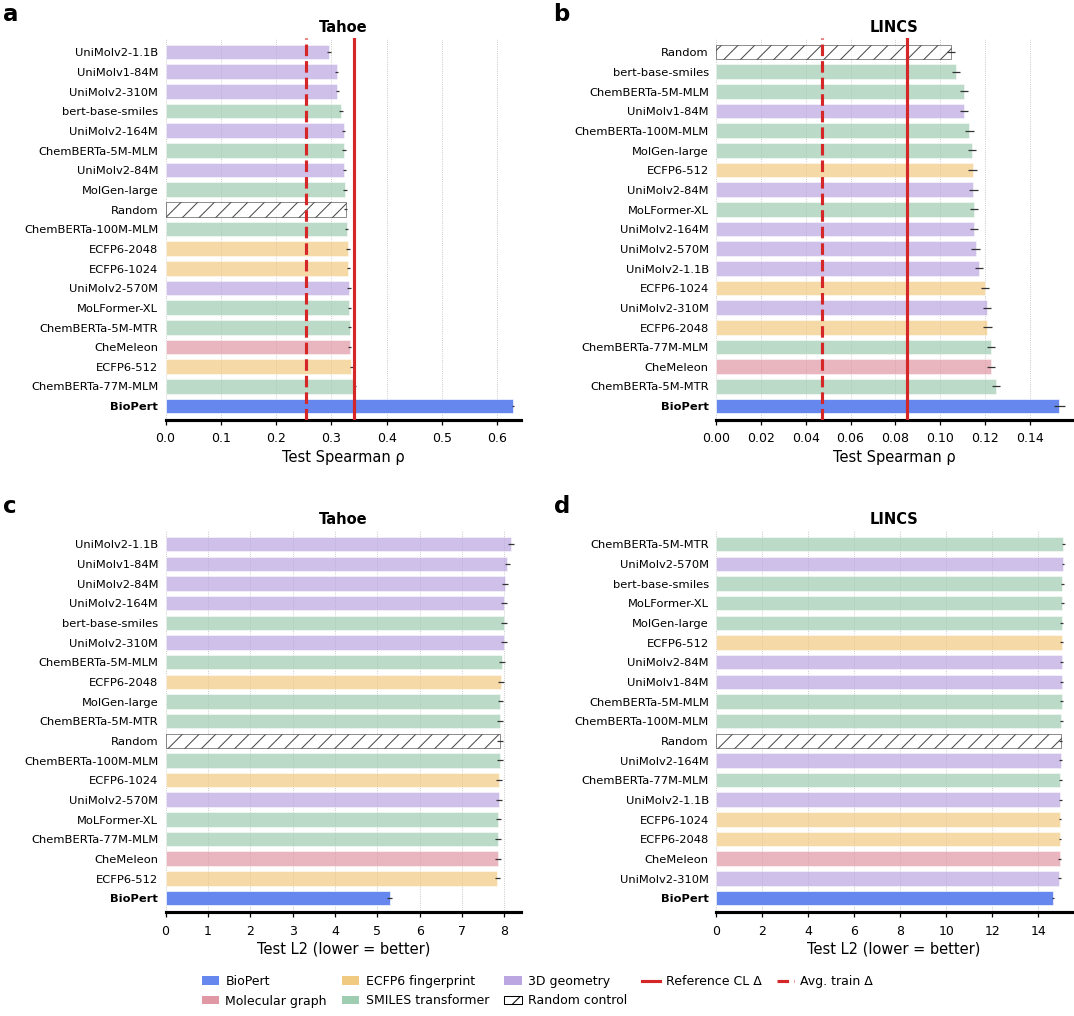

In [157]:
fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL, 6.8))
for j, ds in enumerate(["Tahoe", "LINCS"]):
    representation_panel(axes[0, j], ds, metric="test_spearman", include_landmark=False)
    representation_panel(axes[1, j], ds, metric="test_l2",
                         draw_baselines=False, lower_better=True, include_landmark=False)
repr_legend(fig, baselines=True, include_landmark=False, ncol=5)
label_panels(axes, dx=-78, dy=6)
save_figure(fig, "figS_metric_robustness")
plt.show()

### Suppl. — Full structure–activity relationship analysis

Pearson correlation between chemical distance and pairwise Δ-profile Pearson similarity for every evaluated fingerprint and embedding, expanding Fig. 2a. Error bars are 95% paired percentile bootstrap CIs (1,000 resamples); binary fingerprints use Tanimoto distance and continuous embeddings use cosine distance. ECFP6 is pinned at the top; all other rows are ordered by LINCS correlation.

saved final_figures/figS_sar_full.{pdf,png}


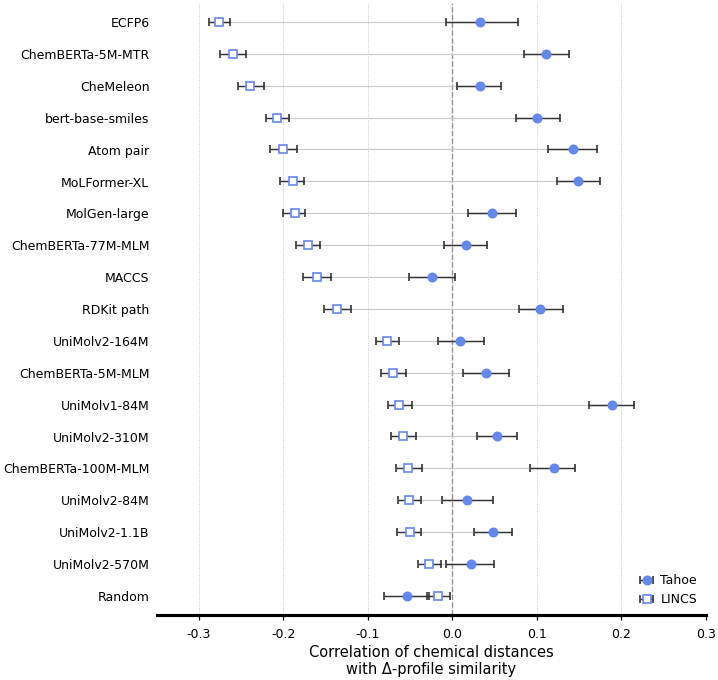

In [158]:
with no_constrained_layout():
    fig, ax = plt.subplots(figsize=(INTER_COL, 5.3))

    y = np.arange(len(corr_df_full))
    for yi, metric in zip(y, corr_df_full.index):
        ax.plot(corr_df_full.loc[metric, list(DATASETS)], [yi, yi],
                color="#cccccc", lw=0.6, zorder=1)

    for ds, marker in zip(DATASETS, ("o", "s")):
        estimate = corr_df_full[ds].to_numpy()
        xerr = np.vstack([
            estimate - ci_lo_full[ds].to_numpy(),
            ci_hi_full[ds].to_numpy() - estimate,
        ])
        ax.errorbar(
            estimate, y, xerr=xerr, fmt=marker, ms=4, capsize=2,
            color=(BLUE if ds == "tahoe" else "white"),
            ecolor="#333333", markeredgecolor=BLUE, markeredgewidth=0.8,
            elinewidth=0.7, label=DS_LABELS[ds], zorder=3,
        )

    ax.axvline(0, color="#999999", lw=0.7, ls="--", zorder=0)
    ax.set_yticks(y)
    ax.set_yticklabels([EROW_LABELS[m.removesuffix("_dist")] for m in corr_df_full.index],
                       fontsize=6)
    ax.set_ylim(-0.6, len(corr_df_full) - 0.4)
    ax.set_xlim(-0.35, 0.30)
    ax.set_xlabel("Correlation of chemical distances\nwith Δ-profile similarity")
    ax.legend(frameon=False, fontsize=6, loc="lower right")
    style_hbar_ax(ax)
    ax.tick_params(axis="x", labelsize=6)
    save_figure(fig, "figS_sar_full")
    plt.show()

### Suppl. — Reproducibility dependence across representations (LINCS)

The same analysis as Fig 4a — mean test Pearson per 0.1-wide bin of test-condition replicate reproducibility — repeated independently for every LINCS ablation/embedding config from Fig 3 (dose/time-encoded `gate` arms), one panel per config. Each panel bins and fits only that config's own test predictions; bin retention (n ≥ 20) and the 95% bootstrap CI follow the same rule as Fig 4a. Panels are ordered by overall test Pearson (default first).

In [159]:
# Data: Fig 4a's binning logic, generalized to every LINCS ablation/embedding
# config (Fig 3's representation set), not just lincs_default_config. Reuses the
# already-computed `repro_obs` (per-condition inter-plate reproducibility) from
# the Fig 4a data cell — same bin edges, same n>=20 retention rule.
REPRO_CONFIGS = (
    res[(res.dataset == "LINCS") & (res.category.isin(["ablation", "embedding"]))]
    .sort_values("test_pearson", ascending=False)
    [["exp_key", "label", "category", "test_pearson"]]
    .reset_index(drop=True)
)

def bin_by_reproducibility(exp_key, edges=bin_edges, min_n=20):
    """Mean test Pearson (+ 95% bootstrap CI) per reproducibility bin, for one
    config's test predictions. Same binning as Fig 4a's `binned`."""
    t = get_perobs(exp_key).merge(
        repro_obs[["cell_line", "drug", "dose", "time", "repro_pearson"]],
        on=["cell_line", "drug", "dose", "time"], how="left"
    ).dropna(subset=["repro_pearson"])
    t["repro_bin"] = pd.cut(t["repro_pearson"], bins=edges)
    rows = []
    for b, g in t.groupby("repro_bin", observed=True):
        if len(g) < min_n:
            continue
        m, lo, hi = fst.bootstrap_ci_mean(
            g["pearson"].to_numpy(), n_boot=N_BOOT, ci=CI, seed=STAT_SEED)
        rows.append({"bin_mid": b.mid, "n": len(g), "mean": m, "lo": lo, "hi": hi})
    return pd.DataFrame(rows).sort_values("bin_mid").reset_index(drop=True)

repro_by_config = {row.exp_key: bin_by_reproducibility(row.exp_key)
                   for row in REPRO_CONFIGS.itertuples()}
print(f"Suppl. reproducibility-by-config: {len(repro_by_config)} LINCS configs "
      f"({sum(len(d) for d in repro_by_config.values())} bins total).")


Suppl. reproducibility-by-config: 20 LINCS configs (260 bins total).


saved final_figures/figS_reproducibility_by_config.{pdf,png}


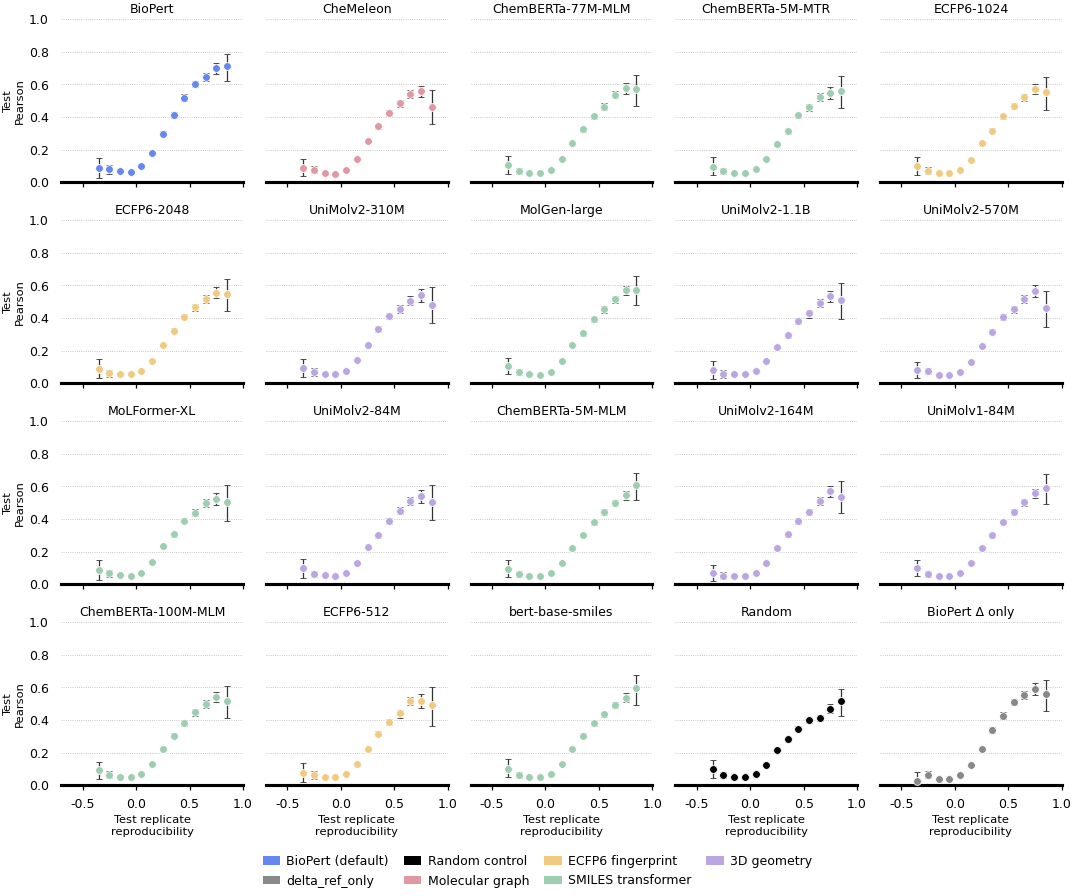

In [160]:
n_cfg = len(REPRO_CONFIGS)
ncols = 5
nrows = (n_cfg // ncols)   # ceil
fig, axes = plt.subplots(nrows, ncols, figsize=(DOUBLE_COL, 1.5 * nrows),
                         sharex=True, sharey=True)
axes_flat = np.ravel(axes)

X_LIM_S = (bin_edges.min(), bin_edges.max())
Y_LIM_S = (0.0, 1.0)

for ax, row in zip(axes_flat, REPRO_CONFIGS.itertuples()):
    d = repro_by_config[row.exp_key]
    color = representation_color(row.category, row.label)
    ax.errorbar(d["bin_mid"], d["mean"],
                yerr=[d["mean"] - d["lo"], d["hi"] - d["mean"]],
                **{**ERR_KW, "ecolor": "#333333", "capthick": 0.4})
    ax.scatter(d["bin_mid"], d["mean"], s=14, color=(color if color != "white" else "black"), zorder=3,
              edgecolor="white", linewidth=0.4)
    ax.set_title(pretty(row.label), fontsize=6)
    ax.set_xlim(*X_LIM_S)
    ax.set_ylim(*Y_LIM_S)
    style_ax(ax)

for ax in axes_flat[n_cfg:]:
    ax.set_visible(False)

for j, ax in enumerate(axes_flat[:n_cfg]):
    if j // ncols == nrows - 1 or j + ncols >= n_cfg:
        ax.set_xlabel("Test replicate\nreproducibility", fontsize=5.5)
    if j % ncols == 0:
        ax.set_ylabel("Test\nPearson", fontsize=5.5)

fig.legend(handles=[Patch(facecolor=BLUE, label="BioPert (default)"),
                    Patch(facecolor=GRAY, label="delta_ref_only"),
                    Patch(facecolor="black", label="Random control"),
                    Patch(facecolor=MODEL_TYPE_COLORS["Molecular graph MPNN"], label="Molecular graph"),
                    Patch(facecolor=MODEL_TYPE_COLORS["Morgan fingerprint"], label="ECFP6 fingerprint"),
                    Patch(facecolor=MODEL_TYPE_COLORS["SMILES transformer"], label="SMILES transformer"),
                    Patch(facecolor=MODEL_TYPE_COLORS["3D geometry (UniMol)"], label="3D geometry")],
           loc="outside lower center", ncol=4, fontsize=6, frameon=False,
           handlelength=1.4, columnspacing=1.2)
save_figure(fig, "figS_reproducibility_by_config")
plt.show()


### Suppl. — Test performance vs. model/input scale

Best-by-val test Pearson against three scale axes, for every LINCS/Tahoe ablation and embedding config (`delta_ref_only` and the landmark-gene variant are excluded, as in Fig 3): **(left)** the trained MLP's own parameter count (from `input_dim`/`hidden_layers`/`output_dim`, so it already reflects both PCA sizes and the architecture); **(middle)** the effective compound-embedding size fed to the model — `n_pca_molec` when the embedding is PCA-reduced, else its native (pre-PCA) dimensionality, else (for `default`, which has no compound embedding at all) `n_pca_expr`, since the reference cell line's delta profile is the only per-compound signal that config gets; **(right)** `n_pca_expr`, the PCA size applied to the expression inputs — the **target** cell line's untreated baseline (`untrt_target`) and the **reference** cell line's drug-induced delta (`delta_ref`) share this one PCA dimensionality (fit as two separate transforms, same target size). Top row Tahoe, bottom row LINCS. Points colored by representation family (Fig 3's scheme).

In [161]:
SCALE_COLS = ["exp_key", "hidden_layers", "input_dim", "output_dim",
             "n_pca_expr", "n_pca_molec"]
scale_raw = best_runs[SCALE_COLS].drop_duplicates("exp_key")

def _parse_hidden_layers(s):
    if pd.isna(s):
        return []
    return [int(x) for x in str(s).strip("[]").split(",") if x.strip()]

def _mlp_param_count(input_dim, hidden_layers, output_dim):
    """Dense layers input_dim -> hidden_layers... -> output_dim, each with a bias
    (Flux `Dense` default) — matches `create_mlp` in src/julia/Models.jl exactly."""
    dims = [int(input_dim)] + hidden_layers + [int(output_dim)]
    return sum(a * b + b for a, b in zip(dims[:-1], dims[1:]))

NO_MOLEC_EMBED_LABELS = {"default", "landmark_genes"}

def _effective_molec_size(row):
    if row["label"] in NO_MOLEC_EMBED_LABELS:
        return row["n_pca_expr"]   # no compound embedding: the reference cell
                                     # line's delta profile (also PCA'd to
                                     # n_pca_expr) is the de facto per-compound
                                     # signal instead.
    if pd.notna(row["n_pca_molec"]):
        return row["n_pca_molec"]   # PCA-reduced to this size.
    return EMBED_NATIVE_DIM.get(row["_embed_label"])   # used at native dimensionality.

EXCLUDE_LABELS = {"delta_ref_only", "landmark_genes"}
scale_df = (res[res.category.isin(["ablation", "embedding"])
               & ~res.label.isin(EXCLUDE_LABELS)]
           [["exp_key", "dataset", "category", "label", "test_pearson"]]
           .merge(scale_raw, on="exp_key", how="left"))
scale_df["hidden_layers_parsed"] = scale_df["hidden_layers"].apply(_parse_hidden_layers)
scale_df["mlp_params"] = [
    _mlp_param_count(r.input_dim, r.hidden_layers_parsed, r.output_dim)
    for r in scale_df.itertuples()
]
scale_df["_embed_label"] = scale_df["label"]
scale_df["compound_embed_size"] = scale_df.apply(_effective_molec_size, axis=1)
scale_df["cell_embed_size"] = scale_df["n_pca_expr"]
scale_df = scale_df.dropna(subset=["mlp_params", "compound_embed_size", "cell_embed_size"])

n_missing_native = scale_df[~scale_df["label"].isin(NO_MOLEC_EMBED_LABELS)
                            & scale_df["n_pca_molec"].isna()
                            & scale_df["compound_embed_size"].isna()].shape[0]
print(f"Scaling data: {len(scale_df)} configs "
      f"({scale_df.dataset.value_counts().to_dict()}), "
      f"{n_missing_native} missing a native-dim lookup (dropped).")


Scaling data: 38 configs ({'LINCS': 19, 'Tahoe': 19}), 0 missing a native-dim lookup (dropped).


saved final_figures/figS_scaling.{pdf,png}


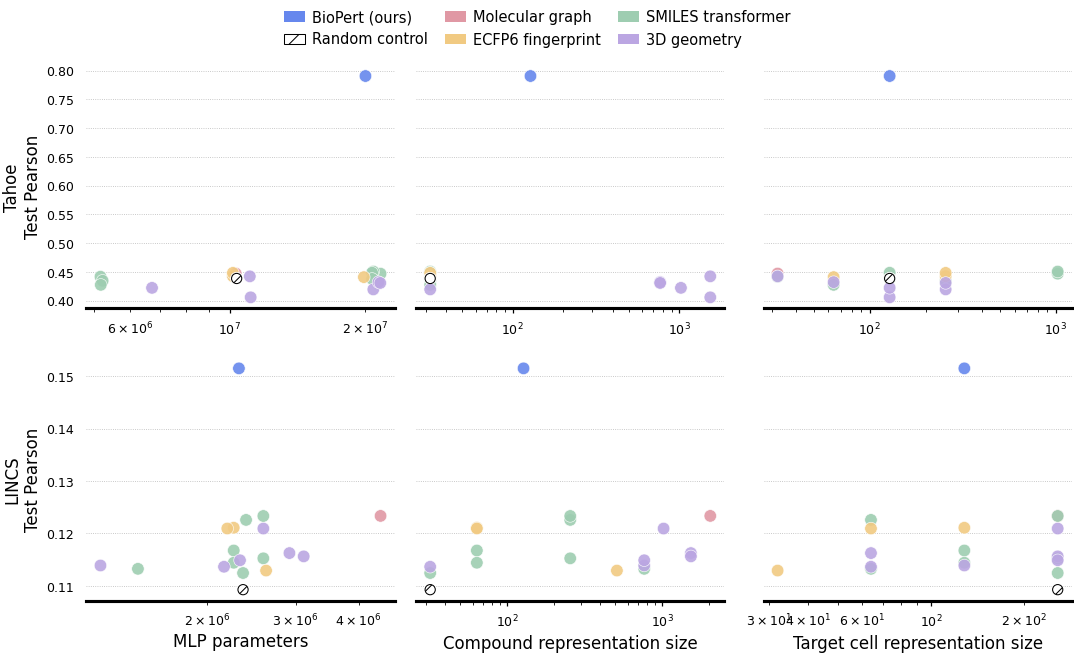

In [162]:
fig, axes = plt.subplots(2, 3, figsize=(DOUBLE_COL, 4.4), sharey="row")
SCALE_X = [("mlp_params", "MLP parameters"),
          ("compound_embed_size", "Compound representation size"),
          ("cell_embed_size", "Target cell representation size")]

for i, ds in enumerate(["Tahoe", "LINCS"]):
    sub = scale_df[scale_df.dataset == ds]
    for j, (col, xlab) in enumerate(SCALE_X):
        ax = axes[i, j]
        colors = [representation_color(c, l) for c, l in zip(sub.category, sub.label)]
        ax.scatter(sub[col], sub["test_pearson"], s=36, color=colors, alpha=0.9,
                  **SCATTER_KW)
        if "random_512" in sub.label.values:
            r = sub[sub.label == "random_512"].iloc[0]
            ax.scatter([r[col]], [r["test_pearson"]], s=24, color="white",
                      edgecolor="black", linewidth=0.5, hatch="///", zorder=4)
        ax.set_xscale("log")
        if j == 0:
            ax.set_ylabel(f"{ds}\nTest Pearson", fontsize=8)
        if i == 1:
            ax.set_xlabel(xlab, fontsize=8)
        style_ax(ax)

fig.legend(handles=[Patch(facecolor=BLUE, label="BioPert (ours)"),
                    Patch(facecolor="white", edgecolor="black", hatch="///",
                          label="Random control"),
                    Patch(facecolor=MODEL_TYPE_COLORS["Molecular graph MPNN"], label="Molecular graph"),
                    Patch(facecolor=MODEL_TYPE_COLORS["Morgan fingerprint"], label="ECFP6 fingerprint"),
                    Patch(facecolor=MODEL_TYPE_COLORS["SMILES transformer"], label="SMILES transformer"),
                    Patch(facecolor=MODEL_TYPE_COLORS["3D geometry (UniMol)"], label="3D geometry")],
           loc="outside upper center", ncol=3, fontsize=7, frameon=False,
           handlelength=1.4, columnspacing=1.2)
save_figure(fig, "figS_scaling")
plt.show()


### Suppl. — Explicit dose/time encoding vs. no encoding

Does giving the model dose (and, on LINCS, exposure time) explicitly, on top of a compound embedding, improve prediction? For each compound representation (**Random** control, **ECFP6-1024**, **CheMeleon**, **UniMolv2-1.1B**) and **BioPert** (`default`: reference-cell Δ + untreated target, no compound embedding) we compare the plain embedding (**none**) against the same model plus one of three explicit encodings: scalar **concat**-enation of log-dose (and one-hot time), a multiplicative log-dose **gate** (CPA-style), or **onehot** log-dose decade bins. BioPert has no dose-encoding experiments (no compound embedding to attach one to), so it contributes only a **none** bar. Bars show validation Pearson (95% bootstrap CI); the percentage above each encoded bar is the relative change vs. that model's **none** bar. Tahoe has a single timepoint (24 h), so only dose is encoded there; LINCS varies both.

This figure is the justification for the paper-wide dose/time correction, and so is the one place that still shows the dose-blind (**none**) runs: it reads `results.best_runs` directly rather than the corrected `res`. `gate` won here, which is why it is the encoding carried into Fig 3 and extended to the full embedding roster.

In [163]:
_raw = results.best_runs

DOSE_MODELS = ["default", "random_512", "Morgan_1024", "CheMeleon", "unimolv2_1.1B"]
DOSE_MODEL_LABEL = {"default": "BioPert", "random_512": "Random",
                    "Morgan_1024": "ECFP6-1024", "CheMeleon": "CheMeleon",
                    "unimolv2_1.1B": "UniMolv2-1.1B"}
DOSE_ENCODINGS = ["none", "concat", "onehot", "gate"]
ENCODING_LABEL = {"none": "none", "concat": "concat", "onehot": "onehot", "gate": "gate"}

def _dose_exp_key(ds_prefix, model, encoding):
    if model == "default":
        return f"{ds_prefix}_default_config" if encoding == "none" else None
    return f"{ds_prefix}_{model}" if encoding == "none" else f"{ds_prefix}_{model}_dose_{encoding}"

_dose_rows = []
_missing_dose_keys = []
for ds, ds_prefix in [("Tahoe", "tahoe"), ("LINCS", "lincs")]:
    for model in DOSE_MODELS:
        for encoding in DOSE_ENCODINGS:
            ek = _dose_exp_key(ds_prefix, model, encoding)
            if ek is None:   # BioPert has no dose-encoding arms
                continue
            row = _raw[_raw["exp_key"] == ek]
            if row.empty:
                _missing_dose_keys.append(ek)
                continue
            row = row.iloc[0]
            _dose_rows.append({
                "dataset": ds, "model": model, "encoding": encoding, "exp_key": ek,
                "val_pearson": np.nan, "lo": np.nan, "hi": np.nan,
            })

dose_df = pd.DataFrame(_dose_rows)
if _missing_dose_keys:
    print(f"Suppl. dose-encoding figure: {len(_missing_dose_keys)} exp_key(s) not yet available:")
    print(f"  {_missing_dose_keys}")

_DOSE_PEROBS, _DOSE_VAL_INDEX = {}, {}
for _ds in ["Tahoe", "LINCS"]:
    _keys = dose_df.loc[dose_df.dataset.eq(_ds), "exp_key"].drop_duplicates().tolist()
    if not _keys:
        continue
    _DOSE_PEROBS[_ds], _DOSE_VAL_INDEX[_ds] = _build_shared_split_views(
        _keys, f"{_ds} dose/time encoding comparison", split="val")
    for _ek, _df in _DOSE_PEROBS[_ds].items():
        _mean, _lo, _hi = fst.bootstrap_ci_mean(
            _df["pearson"].to_numpy(), n_boot=N_BOOT, ci=CI, seed=STAT_SEED)
        _row = dose_df.exp_key.eq(_ek)
        dose_df.loc[_row, ["val_pearson", "lo", "hi"]] = [_mean, _lo, _hi]
    _indices = [_obs_index(df, ek) for ek, df in _DOSE_PEROBS[_ds].items()]
    assert all(idx.equals(_indices[0]) for idx in _indices[1:])

_none_pearson = (
    dose_df[dose_df.encoding == "none"][["dataset", "model", "val_pearson"]]
    .rename(columns={"val_pearson": "none_pearson"})
)
dose_df = dose_df.merge(_none_pearson, on=["dataset", "model"], how="left")
dose_df["pct_vs_none"] = 100 * (dose_df["val_pearson"] - dose_df["none_pearson"]) / dose_df["none_pearson"]
print(f"Suppl. dose-encoding figure: {len(dose_df)} (dataset, model, encoding) rows available.")

dose_df.head()

Tahoe dose/time encoding comparison: 5,260 exact shared val observations across 17 arms.
LINCS dose/time encoding comparison: 28,630 exact shared val observations across 17 arms.
Suppl. dose-encoding figure: 34 (dataset, model, encoding) rows available.


,dataset,model,encoding,exp_key,val_pearson,lo,hi,none_pearson,pct_vs_none
0,Tahoe,default,none,tahoe_default_config,0.777127,0.774310,0.779854,0.777127,0.000000
1,Tahoe,random_512,none,tahoe_random_512,0.353781,0.347292,0.360035,0.353781,0.000000
2,Tahoe,random_512,concat,tahoe_random_512_dose_concat,0.350375,0.344059,0.356589,0.353781,-0.962980
3,Tahoe,random_512,onehot,tahoe_random_512_dose_onehot,0.349070,0.342567,0.355502,0.353781,-1.331621
4,Tahoe,random_512,gate,tahoe_random_512_dose_gate,0.362534,0.355527,0.368981,0.353781,2.474085


saved final_figures/figS_dose_encoding.{pdf,png}


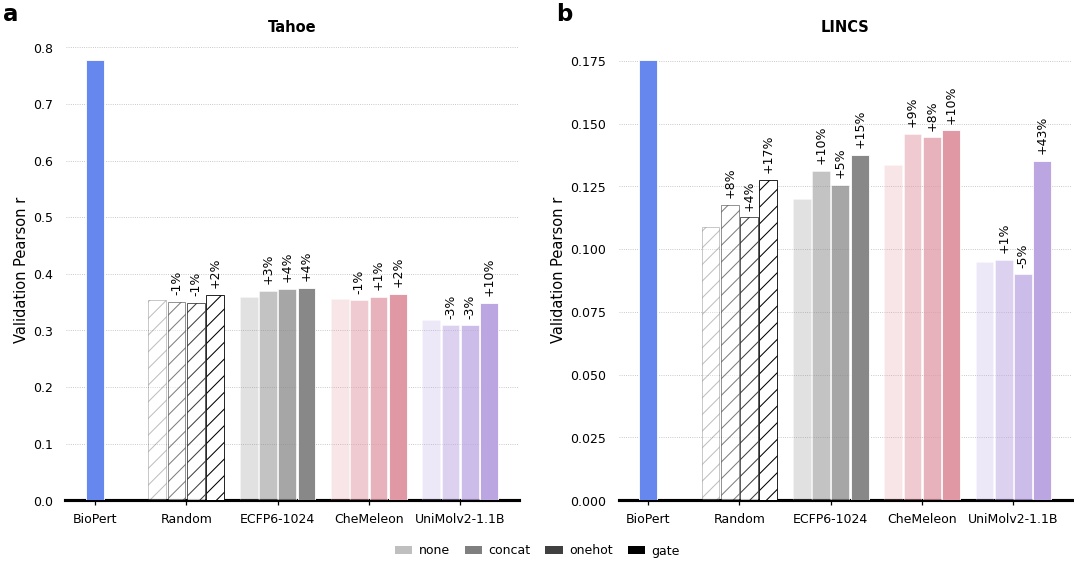

In [164]:
ENCODING_ALPHA = {"none": 0.25, "concat": 0.5, "onehot": 0.75, "gate": 1}
BAR_W = 0.19
GROUP_GAP = 0.9

def _group_color(group):
    if group == "default":
        return BLUE
    if group == "random_512":
        return "white"
    return MODEL_TYPE_COLORS.get(EMBED_TYPE.get(DOSE_MODEL_LABEL[group], ""), GRAY)

def dose_encoding_panel(ax, dataset):
    sub = dose_df[dose_df.dataset == dataset]
    groups = [g for g in DOSE_MODELS if not sub[sub.model == g].empty]

    x0 = np.arange(len(groups)) * GROUP_GAP

    for gi, group in enumerate(groups):
        base_color = _group_color(group)
        gsub = sub[sub.model == group].set_index("encoding")
        present = [e for e in DOSE_ENCODINGS if e in gsub.index]
        offsets = (np.arange(len(present)) - (len(present) - 1) / 2) * BAR_W
        for ei, encoding in enumerate(present):
            xpos = x0[gi] + offsets[ei]
            r = gsub.loc[encoding]
            yerr = None
            if np.isfinite(r["lo"]) and np.isfinite(r["hi"]):
                yerr = [[max(0.0, r["val_pearson"] - r["lo"])],
                       [max(0.0, r["hi"] - r["val_pearson"])]]
            bar = ax.bar(xpos, r["val_pearson"], width=BAR_W * 0.92,
                         color=base_color, alpha=(ENCODING_ALPHA[encoding] if group != "default" else 1.0),
                         edgecolor="black" if group == "random_512" else "white",
                         linewidth=0.4, zorder=3, #yerr=yerr,
                         error_kw={**BAR_ERR_KW, "capthick": 0, "zorder": 5})
            if group == "random_512":
                bar[0].set_hatch("///")
            ymax = ax.get_ylim()[1]
            if encoding != "none" and np.isfinite(r["pct_vs_none"]):
                sign = "+" if r["pct_vs_none"] >= 0 else ""
                ax.text(xpos, r["val_pearson"] + 0.015 * ymax, #(r["hi"] - r["val_pearson"] if np.isfinite(r["hi"]) else 0)
                       f"{sign}{r['pct_vs_none']:.0f}%", ha="center", va="bottom",
                       fontsize=6, rotation=90, zorder=6)

    ax.set_xticks(x0)
    ax.set_xticklabels([DOSE_MODEL_LABEL[g] for g in groups])
    ax.set_ylabel("Validation Pearson r")
    ax.set_title(dataset, fontweight="bold")
    ax.set_ylim(0, None)

    style_ax(ax)
    return groups

fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL, 3.8))
dose_encoding_panel(axes[0], "Tahoe")
dose_encoding_panel(axes[1], "LINCS")

encoding_handles = [Patch(facecolor="black", alpha=ENCODING_ALPHA[e], label=ENCODING_LABEL[e])
                    for e in DOSE_ENCODINGS]
fig.legend(handles=encoding_handles, loc="outside lower center", ncol=6,
          fontsize=6, frameon=False, handlelength=1.4, columnspacing=1.2)
label_panels(axes, dx=-30, dy=6)
save_figure(fig, "figS_dose_encoding")
plt.show()

---

All figures are saved to `final_figures/` as vector PDF + 600-dpi PNG (embedded fonts, shared palette and lettering from `figure_style.py`).

## Export — every confidence interval and statistical test to CSV

Writes one tidy CSV per analysis to `final_figures/stats/`, plus a combined long-format `all_statistics.csv` for the supplement. Runs last, since it collects every figure cell's statistics.

In [166]:
# Export all CIs and statistical tests to CSV.
STATS_DIR = os.path.join("final_figures", "stats")
os.makedirs(STATS_DIR, exist_ok=True)

_written = {}
def _write(name, df):
    df.to_csv(os.path.join(STATS_DIR, name), index=False)
    _written[name] = len(df)
    return df

_all = []   # rows for the combined long-format table
def _add(figure, analysis, group, term, estimate, ci_lo=np.nan, ci_hi=np.nan,
         p=np.nan, p_adj=np.nan, n=np.nan):
    _all.append(dict(figure=figure, analysis=analysis, group=group, term=term,
                     estimate=estimate, ci_lo=ci_lo, ci_hi=ci_hi, p=p,
                     p_adj=p_adj, n=n))

# 1. Bootstrap CIs of every experiment's mean test metric (Fig 2d/e, suppl. figures).
# NOTE: the "fig3" CSV names/keys below are kept as-is after the Fig 2+3 merge so
# existing manuscript/supplement citations of these filenames stay valid.
ci_rows = [
    dict(dataset=r["dataset"], category=r["category"], label=r["label"],
         exp_key=r["exp_key"], metric=m, estimate=r[m],
         ci_lo=r[f"{m}_lo"], ci_hi=r[f"{m}_hi"])
    for _, r in res.iterrows() for m in METRIC_OBS_COL
]
exp_ci = _write("experiment_metric_cis.csv",
                pd.DataFrame(ci_rows).sort_values(["dataset", "metric", "label"]))
for _, r in exp_ci.iterrows():
    _add("fig3/figS", "bootstrap CI of mean test metric", r["dataset"],
         f"{r['label']} · {r['metric']}", r["estimate"], r["ci_lo"], r["ci_hi"])

# 2. Fig 2d/e — each representation vs the random_512 control (paired Wilcoxon, BH).
repr_df = _write("fig3_representation_vs_random.csv", pd.DataFrame([
    dict(dataset=ds, label=lbl, mean_pearson=d["mean_a"],
         mean_random_512=d["mean_b"], mean_diff=d["mean_diff"],
         ci_lo=d["lo"], ci_hi=d["hi"], p_wilcoxon=d["p"], p_adj_bh=d["p_adj"],
         stars=fst.stars(d["p_adj"]), n_pairs=d["n_pairs"])
    for (ds, lbl), d in repr_tests.items()
]).sort_values(["dataset", "mean_diff"], ascending=[True, False]))
for _, r in repr_df.iterrows():
    _add("fig3", "paired Δ mean test Pearson vs random_512", r["dataset"],
         r["label"], r["mean_diff"], r["ci_lo"], r["ci_hi"], r["p_wilcoxon"],
         r["p_adj_bh"], r["n_pairs"])

# 3. Headline paired comparisons: default vs best embedding and vs the baselines.
head_df = _write("headline_comparisons.csv", pd.DataFrame([
    dict(dataset=ds, comparison=comp, other=d.get("other", comp.split("_vs_")[-1]),
         mean_default=d["mean_a"], mean_other=d["mean_b"],
         mean_diff=d["mean_diff"], ci_lo=d["lo"], ci_hi=d["hi"],
         p_wilcoxon=d["p"], stars=fst.stars(d["p"]), n_pairs=d["n_pairs"])
    for (ds, comp), d in headline_tests.items()
]).sort_values(["dataset", "comparison"]))
for _, r in head_df.iterrows():
    _add("fig3", "paired Δ mean test Pearson (default − other)", r["dataset"],
         r["comparison"], r["mean_diff"], r["ci_lo"], r["ci_hi"], r["p_wilcoxon"],
         n=r["n_pairs"])

# 4. Fig 2f/g — Systema sensitivity and unseen-cell-line gains.
systema_df = _write("fig2_systema.csv", fig2_systema.copy())
for _, r in systema_df.iterrows():
    _add("fig2f", "compound-cluster bootstrap CI", r["group"], r["label"],
         r["estimate"], r["lo"], r["hi"], n=r["n_conditions"])

unseen_df = _write("fig2_unseen_cellline_gain.csv", fig2_generalization.copy())
for _, r in unseen_df.iterrows():
    _add("fig2g", "cell-line bootstrap CI of macro Pearson gain vs reference Δ",
         r["dataset"], r["quadrant"], r["estimate"], r["lo"], r["hi"],
         n=r["n_cell_lines"])

# 5. Fig 3a — per-bin mean test Pearson with bootstrap CI, plus the trend stats.
bins_df = binned.reset_index().rename(columns={"lo": "ci_lo", "hi": "ci_hi"})
bins_df["repro_bin"] = bins_df["repro_bin"].astype(str)
_write("fig4a_repro_bins.csv", bins_df[["repro_bin", "bin_mid", "repro_center",
                                        "n", "model_pearson", "ci_lo", "ci_hi"]])
for _, r in bins_df.iterrows():
    _add("fig3a", "bootstrap CI of mean test Pearson within reproducibility bin",
         "LINCS", r["repro_bin"], r["model_pearson"], r["ci_lo"], r["ci_hi"],
         n=r["n"])
_add("fig3a", "per-condition Spearman ρ (test Pearson vs replicate reproducibility)",
     "LINCS", "spearman_rho", sp_repro["rho"], sp_repro["lo"], sp_repro["hi"],
     sp_repro["p"], n=sp_repro["n"])
_add("fig3a", "R² of the linear fit through the binned means (descriptive)",
     "LINCS", "binned_r2", r2, n=len(binned))
_add("fig3a", "regression slope of the binned means, bootstrap CI",
     "LINCS", "binned_slope", lf_repro["slope"], lf_repro["lo"], lf_repro["hi"],
     n=lf_repro["n"])

# 6. Fig 3c — per-band paired test, θ=0.5 training filter vs no filter.
filt_df = _write("fig4c_repro_filter_tests.csv", pd.DataFrame([
    dict(repro_bin=str(b), bin_mid=b.mid, mean_no_filter=d["mean_a"],
         mean_theta_0p5=d["mean_b"], mean_diff=d["mean_diff"],
         ci_lo=d["lo"], ci_hi=d["hi"], p_wilcoxon=d["p"], p_adj_bh=d["p_adj"],
         stars=fst.stars(d["p_adj"]), n_pairs=d["n_pairs"])
    for b, d in repro_filter_tests.items()
]).sort_values("bin_mid"))
for _, r in filt_df.iterrows():
    _add("fig3c", "paired Δ mean test Pearson (no filter − θ=0.5)", "LINCS",
         r["repro_bin"], r["mean_diff"], r["ci_lo"], r["ci_hi"], r["p_wilcoxon"],
         r["p_adj_bh"], r["n_pairs"])

# 7. Fig 3d — Tahoe target sequencing depth vs accuracy: Spearman + best curve fit.
_add("fig3d", "Spearman ρ with bootstrap CI", "Tahoe",
     "test Pearson vs mean sequencing depth (UMIs)", sp_depth["rho"],
     sp_depth["lo"], sp_depth["hi"], sp_depth["p"], n=sp_depth["n"])
fit_df = _write("fig4d_depth_curve_fits.csv", pd.DataFrame([
    dict(name=d["name"], equation=d["eqn"], r2=d["r2"], adj_r2=d["adj_r2"],
         params="; ".join(f"{v:.4g}" for v in d["popt"]),
         chosen=(d["name"] == depth_fit["name"]))
    for d in _fits
]))
_add("fig3d", "best depth→accuracy curve (highest adjusted R²)", "Tahoe",
     f"{depth_fit['name']}: {depth_fit['eqn']}", depth_fit["r2"], n=len(cl_depth))

# 8. Fig 4a,b — Friedman test across reference cell lines, blocked by target line.
fried_df = _write("fig5ab_friedman.csv", pd.DataFrame([
    dict(dataset=ds, chi2=f["stat"], p=f["p"], kendall_W=f["W"], n_references=f["k"],
         n_target_lines=f["n_blocks"], median_accuracy_spread=spread)
    for ds, f, spread in [("Tahoe", fried_tahoe, spread_tahoe),
                          ("LINCS", fried_lincs, spread_lincs)]
]))
for _, r in fried_df.iterrows():
    _add("fig4ab", "Friedman test across references, blocked by target cell line",
         r["dataset"], "chi2", r["chi2"], p=r["p"], n=r["n_target_lines"])
    _add("fig4ab", "Kendall's W (effect size)", r["dataset"], "kendall_W",
         r["kendall_W"], n=r["n_target_lines"])
    _add("fig4ab", "median test-Pearson spread across references", r["dataset"],
         "median_spread", r["median_accuracy_spread"], n=r["n_target_lines"])

# 9. Fig 4c — Spearman correlation (accuracy vs reference–target similarity), CI.
sp_df = _write("fig5c_spearman.csv", pd.DataFrame([
    dict(panel="c", dataset="Tahoe",
         relation="test Pearson vs reference–target Δ-profile similarity",
         rho=sp_sim["rho"], ci_lo=sp_sim["lo"], ci_hi=sp_sim["hi"], p=sp_sim["p"],
         n=sp_sim["n"]),
]))
for _, r in sp_df.iterrows():
    _add(f"fig4{r['panel']}", "Spearman ρ with bootstrap CI", r["dataset"],
         r["relation"], r["rho"], r["ci_lo"], r["ci_hi"], r["p"], n=r["n"])

# 10. Fig 4d — LINCS reference handling: best-run CIs and paired experiment differences.
rh_df = _write("fig5d_ref_handling.csv", pd.DataFrame([
    dict(arm=REF_HANDLING[ek].replace("\n", " "),
         val_spearman=rh_best.loc[ek, "val_spearman"], test_pearson=rh_ci[ek][0],
         ci_lo=rh_ci[ek][1], ci_hi=rh_ci[ek][2])
    for ek in rh_best.index]))
for _, r in rh_df.iterrows():
    _add("fig4d", "best-by-val run, mean test Pearson", "LINCS", r["arm"],
         r["test_pearson"], r["ci_lo"], r["ci_hi"])
for (a, b), d in rh_tests.items():
    _add("fig4d", "paired delta test Pearson (shared test split)", "LINCS",
         f"{REF_HANDLING[a]} - {REF_HANDLING[b]}".replace("\n", " "),
         d["mean_diff"], d["lo"], d["hi"], d["p"], n=d["n_pairs"])

# 11. Fig 4e,f — case-01 pathway and mechanistic-gene values.
case01_pathway_metrics_df = _write(
    "fig4e_case01_pathway_concordance.csv", case01_pathway_metrics.copy())
for _, r in case01_pathway_metrics_df.iterrows():
    _add("fig4e", "pathway NES Spearman correlation with measured C32",
         r["collection"], r["comparison"], r["spearman_rho"],
         n=r["n_pathways"])
    _add("fig4e", "mean absolute pathway NES error vs measured C32",
         r["collection"], r["comparison"], r["mae"],
         n=r["n_pathways"])

_write("fig4e_case01_pathway_points.csv", case01_pathways.copy())
case01_modules_df = _write(
    "fig4f_case01_gene_modules.csv",
    case01_module_scores.sort_values(["gene_order", "profile"])
)
for _, r in case01_modules_df.iterrows():
    _add("fig4f", "signed GSEA ranking score (treated - DMSO)",
         r["module"], f"{r['gene']} · {r['profile']}",
         r["signed_rank_score"])

# 12. Supplementary complete variance partition and absolute-profile reproducibility.
vp_full_df = _write("figS_variance_partition_full.csv",
                    vp_full_summary.copy())
for _, r in vp_full_df[vp_full_df["available"]].iterrows():
    _add("figS_variance_partition_full",
         "median per-gene variance component (IQR)",
         f"{r['dataset']} · {r['profile_type']}", r["factor"],
         r["median"], r["q25"], r["q75"], n=r["n_genes"])

abs_repro_df = _write("figS_absolute_reproducibility_grid.csv",
                     abs_repro_summary.copy())
for _, r in abs_repro_df.iterrows():
    _add("figS_absolute_reproducibility_grid",
         "median absolute-profile replicate Pearson (IQR)",
         r["dataset"], f"{r['treatment']} · {r['plate_scope']}",
         r["median"], r["q25"], r["q75"], n=r["n_pairs"])

sar_full_df = _write("figS_sar_full.csv", pd.DataFrame([
    dict(
        dataset=DS_LABELS[ds],
        representation=EROW_LABELS[metric.removesuffix("_dist")],
        distance_metric=("Tanimoto" if metric.removesuffix("_dist") in FP_ROWS else "cosine"),
        estimate=corr_df_full.loc[metric, ds],
        ci_lo=ci_lo_full.loc[metric, ds],
        ci_hi=ci_hi_full.loc[metric, ds],
        n_pairs=len(sar[ds]),
        n_boot=N_BOOT,
    )
    for metric in corr_df_full.index for ds in DATASETS
]))
for _, r in sar_full_df.iterrows():
    _add("figS_sar_full", "Pearson correlation of chemical distance with Δ-profile similarity",
         r["dataset"], r["representation"], r["estimate"],
         r["ci_lo"], r["ci_hi"], n=r["n_pairs"])

# Combined long-format table.
all_stats = pd.DataFrame(_all)
all_stats["ci_level"] = CI
all_stats["seed"] = STAT_SEED
_write("all_statistics.csv", all_stats)

print(f"Wrote {len(_written)} CSV files to {STATS_DIR}/")
for name, n in _written.items():
    print(f"  {name:38s} {n:5d} rows")


Wrote 18 CSV files to final_figures/stats/
  experiment_metric_cis.csv                432 rows
  fig3_representation_vs_random.csv         36 rows
  headline_comparisons.csv                   8 rows
  fig2_systema.csv                           5 rows
  fig2_unseen_cellline_gain.csv              6 rows
  fig4a_repro_bins.csv                      13 rows
  fig4c_repro_filter_tests.csv              11 rows
  fig4d_depth_curve_fits.csv                 5 rows
  fig5ab_friedman.csv                        2 rows
  fig5c_spearman.csv                         1 rows
  fig5d_ref_handling.csv                     3 rows
  fig4e_case01_pathway_concordance.csv       6 rows
  fig4e_case01_pathway_points.csv         1227 rows
  fig4f_case01_gene_modules.csv             48 rows
  figS_variance_partition_full.csv          24 rows
  figS_absolute_reproducibility_grid.csv     8 rows
  figS_sar_full.csv                         38 rows
  all_statistics.csv                       657 rows


## Hyperparameter tables — best-by-val run per configuration

Two LaTeX longtables (Tahoe, LINCS), one row per embedding config (Fig 3's roster, minus `delta_ref_only`), columns = the 7 swept hyperparameters + the selected (early-stopped) epoch of that config's best-by-val run. For BioPert and the landmark-gene variant — which have no compound embedding — the n_pca_molec column shows `n_pca_expr` instead of a blank: the reference cell line's drug-induced delta profile is their de facto molecule representation, and it is PCA-reduced to that size. Written to `final_figures/tables/`. Requires the `longtable` and `booktabs` packages in the manuscript preamble (`\usepackage{longtable}`, `\usepackage{booktabs}`).

In [167]:
TABLES_DIR = os.path.join("final_figures", "tables")
os.makedirs(TABLES_DIR, exist_ok=True)

HP_COLS = ["lr", "batch_size", "weight_decay", "hidden_layers", "n_epochs",
          "n_pca_expr", "n_pca_molec", "selected_epoch"]
HP_HEADER = {"lr": "LR", "batch_size": "BSZ", "weight_decay": "Weight decay",
            "hidden_layers": "Hidden layers", "n_epochs": "Max epochs",
            "n_pca_expr": "$n_\\mathrm{PCA}^{\\mathrm{expr}}$",
            "n_pca_molec": "$n_\\mathrm{PCA}^{\\mathrm{molec}}$",
            "selected_epoch": "Epoch"}

FP_SIZE_SORTED = ("Morgan_512", "Morgan_1024", "Morgan_2048")
def table_label(label):
    return pretty(label)

def sort_key(label):
    if label in FP_SIZE_SORTED:
        return (0, int(label.rsplit("_", 1)[1]))
    return (1, table_label(label))

hp_table = best_runs[(best_runs.category.isin(["ablation", "embedding"]))
                     & (best_runs.label != "delta_ref_only")][
    ["dataset", "label", "category"] + HP_COLS
].copy()

NO_MOLEC_EMBED_LABELS = {"default", "landmark_genes"}   # delta_ref_only excluded above
hp_table["n_pca_molec"] = hp_table["n_pca_molec"].where(
    ~hp_table["label"].isin(NO_MOLEC_EMBED_LABELS), hp_table["n_pca_expr"])

def _fmt_hp(col, v):
    if col == "hidden_layers":
        nums = str(v).strip("[]").split(",")
        return "[" + ", ".join(str(int(x)) for x in nums if x.strip()) + "]"
    if col == "lr":
        return f"{v:.2e}"
    if col == "weight_decay":
        return f"{v:g}"
    if col == "n_pca_molec":
        return "—" if pd.isna(v) else str(int(v))
    return str(int(v))

def write_hp_table(dataset, path):
    sub = (hp_table[hp_table.dataset == dataset]
          .assign(table_label=lambda d: d["label"].map(table_label),
                  _sort_key=lambda d: d["label"].map(sort_key))
          .sort_values("_sort_key"))
    lines = [
        r"\begin{longtable}{l" + "r" * len(HP_COLS) + "}",
        f"\\caption{{Best-by-validation-Spearman hyperparameters, {dataset}.}} "
        f"\\label{{tab:hp_{dataset.lower()}}} \\\\",
        r"\toprule",
        "Configuration & " + " & ".join(HP_HEADER[c] for c in HP_COLS) + r" \\",
        r"\midrule",
        r"\endfirsthead",
        r"\toprule",
        "Configuration & " + " & ".join(HP_HEADER[c] for c in HP_COLS) + r" \\",
        r"\midrule",
        r"\endhead",
        r"\bottomrule",
        r"\endfoot",
    ]
    for _, row in sub.iterrows():
        row_vals = [_fmt_hp(c, row[c]) for c in HP_COLS]
        lines.append(f"{row['table_label']} & " + " & ".join(row_vals) + r" \\")
    lines.append(r"\end{longtable}")
    tex = "\n".join(lines) + "\n"
    with open(path, "w") as f:
        f.write(tex)
    return sub.shape[0]

n_tahoe = write_hp_table("Tahoe", os.path.join(TABLES_DIR, "hp_tahoe.tex"))
n_lincs = write_hp_table("LINCS", os.path.join(TABLES_DIR, "hp_lincs.tex"))
print(f"Wrote {TABLES_DIR}/hp_tahoe.tex ({n_tahoe} rows) "
      f"and {TABLES_DIR}/hp_lincs.tex ({n_lincs} rows).")


Wrote final_figures/tables/hp_tahoe.tex (20 rows) and final_figures/tables/hp_lincs.tex (19 rows).
